# Hyper Instancing Meshes in a BIM Model

The goal of this EDA notebook will be to hyper instance our meshes in the scene, drastically reducing the memory consumption. The first proof of concept will be to replace all the unique straight runs of pipe with one unit cylinder that scales across length, or diameter to meet the input shape dimensions.

## Data and EDA

The data we shall be working with is the IFC data of the [Sixty5](https://github.com/buildingsmart-community/Community-Sample-Test-Files/tree/main/IFC%202.3.0.1%20(IFC%202x3)/SDK%20-%20S1) development- specifically the piping layer.

![Piping Layer of Model](../../../reports/img/model-shots.png)

Since we're working with IFC data, we will need to import the `ifcopenshell` package.

In [1]:
import ifcopenshell
import pymeshlab

As well, let's import our trusty data science tools, pandas and numpy.

In [1]:
import pandas as pd
import numpy as np

Let's open the model using `ifcopenshell`.

In [3]:
model = ifcopenshell.open('data/O-S1-INS-Plumbing - Sanitair.ifc')

We have worked previously with Ifc schema, so we know that the straight pipes in the model are classified under the element "IfcFlowSegment". Using the Blender BIM viewer add-on, [Bonsai](https://bonsaibim.org/), we can confirm that are selection is indeed accurate. Here are the results of selecting only this element in the model.

![IfcFlowSegment results in Bonsai](../img/IfcFlowElement-selection.png)

Zoomed ->

![IfcFlowSegments in the model, zoomed in ](../img/IfcFlowElement-selection-zoomed.png)

Perfect, looks like we have indeed narrowed down to just these straight pipes in the model. Let's create an active selection set using `ifcopenshell`.

In [4]:
pipes = model.by_type("IfcFlowSegment")

How many of these pipes exist in the model?

In [5]:
len(pipes)

10957

We know from earlier analysis that there are roughly 23k objects in the scene in total, meaning that straight pipes account for a significant majority of the geometry in the model. Lets see how many of these are unique geometries.

To do so, we need to import 2 more packages.

In [6]:
import ifcopenshell.geom
import ifcopenshell.util.shape

In [7]:
settings = ifcopenshell.geom.settings()
geom_library="hybrid-cgal-simple-opencascade"

In [8]:
unique_geoms = set()

for pipe in pipes:
    shape = ifcopenshell.geom.create_shape(settings, pipe, geometry_library=geom_library)
    unique_geoms.add(shape.geometry.id)

In [9]:
len(unique_geoms)

10957

Seems like we have absolutely NO objects that share the same geometry. To confirm that my script above is working as intended, I shall test run on another element in the model that I know has duplicated geometry- `IfcFlowFitting`.

In [10]:
fittings = model.by_type("IfcFlowFitting")

# unique_geoms_fittings = set()

# for fitting in fittings:
#     shape = ifcopenshell.geom.create_shape(settings, fitting, geometry_library=geom_library)
#     unique_geoms_fittings.add(shape.geometry.id)

# print(f"total length: {len(fittings)}")
# print(f"unique geometries: {len(unique_geoms_fittings)}")

This seems to indicate that fittings too contain no unique geometries which is not the case. Looking into the the `ifcopenshell` [docs](https://docs.ifcopenshell.org/ifcopenshell-python/geometry_processing.html), we see that the geometry.id of a shape is determined by the world coordinates as well, which obviously means that our geometries will no be the same. Seems like we can pass an argument into the main settings function that enables us to only select objects based on their local coordinates (courtesy of Gemini). 

In [11]:
# settings.set(settings.USE_WORLD_COORDS, False)

# unique_geoms_fittings = set()

# for fitting in fittings:
#     shape = ifcopenshell.geom.create_shape(settings, fitting)
#     unique_geoms_fittings.add(shape.geometry.id)

# print(f"total length: {len(fittings)}")
# print(f"unique geometries: {len(unique_geoms_fittings)}")

Seems like our best course of action here might to create a dedicated iterator object like is referenced in the [docs](https://docs.ifcopenshell.org/ifcopenshell/geometry_settings.html).

In [12]:
iterator = ifcopenshell.geom.iterator(
    settings, model, include=fittings, geometry_library=geom_library)

unique_geoms_fittings = set()

if iterator.initialize():
    while True:
        shape = iterator.get()
        unique_geoms_fittings.add(shape.geometry.id)
        # ... write code to process geometry here ...
        if not iterator.next():
            break

In [13]:
print(f"total length: {len(fittings)}")
print(f"unique geometries: {len(unique_geoms_fittings)}")

total length: 10558
unique geometries: 531


This seems to work... implying that we have 531 unqiue geometries for each fitting in our scene. Let's see what result we get with our straight pipe.

In [14]:
iterator = ifcopenshell.geom.iterator(
    settings, model, include=pipes, geometry_library=geom_library)

unique_geoms = set()

if iterator.initialize():
    while True:
        shape = iterator.get()
        unique_geoms.add(shape.geometry.id)
        # ... write code to process geometry here ...
        if not iterator.next():
            break

In [15]:
print(f"total length: {len(pipes)}")
print(f"unique geometries: {len(unique_geoms)}")

total length: 10957
unique geometries: 10957


This seems to confirm our finding that each pipe in the model is a unique piece of geometry. To absolutely drive this home, lets run the same script on our fittings again, but we set the setting USE_WORLD_COORDS to true instead. This way, we should get the same number of unique geometries as there are objects, since no 2 objects should share the same location in space.

In [16]:
# settings.set(settings.USE_WORLD_COORDS, True)

# unique_geoms_fittings = set()

# iterator = ifcopenshell.geom.iterator(
#     settings, model, include=fittings, geometry_library=geom_library)

# unique_geoms_fittings = set()

# if iterator.initialize():
#     while True:
#         shape = iterator.get()
#         unique_geoms_fittings.add(shape.geometry.id)
#         # ... write code to process geometry here ...
#         if not iterator.next():
#             break

# print(f"total length: {len(fittings)}")
# print(f"unique geometries: {len(unique_geoms_fittings)}")

We proceed with this information.

## Getting Geometry Data

The docs on `ifcopenshell` highlight how to acquire the vertices and faces data from a selected object in the scene. This involves using the same geometry iterator we created above. We shall create a `geom_dict` to save the individual geometries in the scene such that we can access them later.

Here, we also need to keep our previously set setting USE_WORLD_COORDS to False, since the global position should be captured in the transformation matrix.

In [17]:
geom_dict = {}

settings.set(settings.USE_WORLD_COORDS, False)

iterator = ifcopenshell.geom.iterator(
    settings, model, include=pipes, geometry_library=geom_library)

if iterator.initialize():
    while True:
        shape = iterator.get()
        shape_id = shape.geometry.id

        # From the Docs
        matrix = shape.transformation.matrix
        faces = shape.geometry.faces
        edges = shape.geometry.edges
        verts = shape.geometry.verts

        geom_dict[shape_id] = {}
        geom_dict[shape_id]["matrix"] = matrix
        geom_dict[shape_id]["faces"] = faces
        geom_dict[shape_id]["edges"] = edges
        geom_dict[shape_id]["vertices"] = verts

        if not iterator.next():
            break

In [18]:
geom_dict.keys()

dict_keys(['254', '401', '518', '637', '752', '1978', '2096', '3301', '3418', '3533', '3649', '3766', '3883', '3998', '4279', '4394', '4509', '4624', '4739', '5026', '5141', '7017', '7295', '7410', '7769', '7886', '8005', '8323', '8438', '12015', '12130', '12246', '12361', '12476', '18114', '18229', '18344', '24608', '33311', '37294', '37730', '39050', '40832', '41019', '41209', '41399', '43298', '43488', '43678', '43875', '44063', '44253', '44443', '44640', '44828', '45018', '45208', '45405', '45593', '45783', '45973', '46170', '46358', '46548', '46738', '46935', '47123', '47313', '47503', '47700', '47888', '48078', '48268', '48465', '48653', '48843', '49033', '49230', '49417', '49607', '49797', '49994', '50182', '50372', '50562', '50759', '50947', '51137', '51327', '51524', '51712', '51902', '52092', '52289', '52476', '52666', '52856', '53053', '53240', '53430', '53620', '58985', '59172', '59362', '59552', '59891', '60081', '60271', '60468', '60655', '60845', '61035', '61232', '61419

In [19]:
geom_dict['254']

{'matrix': (1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0),
 'faces': (0,
  1,
  2,
  3,
  2,
  1,
  4,
  1,
  0,
  5,
  0,
  6,
  7,
  6,
  8,
  9,
  8,
  10,
  11,
  10,
  12,
  13,
  12,
  14,
  15,
  14,
  16,
  17,
  18,
  16,
  19,
  17,
  20,
  21,
  19,
  22,
  23,
  21,
  24,
  25,
  23,
  26,
  27,
  25,
  28,
  29,
  27,
  30,
  3,
  29,
  31,
  3,
  27,
  29,
  6,
  0,
  2,
  16,
  6,
  2,
  10,
  6,
  16,
  8,
  6,
  10,
  12,
  10,
  16,
  14,
  12,
  16,
  28,
  16,
  2,
  24,
  16,
  28,
  22,
  16,
  24,
  20,
  16,
  22,
  26,
  24,
  28,
  30,
  28,
  2,
  31,
  30,
  2,
  1,
  4,
  3,
  0,
  5,
  4,
  6,
  7,
  5,
  8,
  9,
  7,
  10,
  11,
  9,
  12,
  13,
  11,
  14,
  15,
  13,
  16,
  18,
  15,
  16,
  20,
  17,
  20,
  22,
  19,
  22,
  24,
  21,
  24,
  26,
  23,
  26,
  28,
  25,
  28,
  30,
  27,
  30,
  31,
  29,
  31,
  2,
  3,
  25,
  27,
  3,
  18,
  25,
  3,
  21,
  25,
  18,
  23,
  25,
  2

In [20]:
geom_dict['254']['vertices']

(22.102135191247314,
 21.3839305891755,
 3.8161005050633885,
 22.10517000976586,
 21.3839305891755,
 3.820642431946889,
 22.1062356963107,
 21.3839305891755,
 3.826,
 22.1062356963107,
 25.29892148237586,
 3.826,
 22.10517000976586,
 25.29892148237586,
 3.820642431946889,
 22.102135191247314,
 25.29892148237586,
 3.8161005050633885,
 22.097593264363812,
 21.3839305891755,
 3.8130656865448422,
 22.097593264363812,
 25.29892148237586,
 3.8130656865448422,
 22.092235696310702,
 21.3839305891755,
 3.8120000000000003,
 22.092235696310702,
 25.29892148237586,
 3.8120000000000003,
 22.08687812825759,
 21.3839305891755,
 3.8130656865448422,
 22.08687812825759,
 25.29892148237586,
 3.8130656865448422,
 22.08233620137409,
 21.3839305891755,
 3.8161005050633885,
 22.08233620137409,
 25.29892148237586,
 3.8161005050633885,
 22.079301382855544,
 21.3839305891755,
 3.820642431946889,
 22.079301382855544,
 25.29892148237586,
 3.820642431946889,
 22.078235696310703,
 21.3839305891755,
 3.826,
 22.0793

Seems like our vertices here are in the format of a flattened list. From the docs, we can see that grouping the vertices into groups of 3 is possible ->

In [21]:
geom_dict = {}

iterator = ifcopenshell.geom.iterator(
    settings, model, include=pipes, geometry_library=geom_library)
if iterator.initialize():
    while True:
        shape = iterator.get()
        shape_id = shape.geometry.id

        # From the Docs
        matrix = shape.transformation.matrix
        grouped_faces = ifcopenshell.util.shape.get_faces(shape.geometry)
        grouped_verts = ifcopenshell.util.shape.get_vertices(shape.geometry)

        geom_dict[shape_id] = {}
        geom_dict[shape_id]["matrix"] = matrix
        geom_dict[shape_id]["faces"] = grouped_faces
        geom_dict[shape_id]["vertices"] = grouped_verts

        if not iterator.next():
            break

In [22]:
geom_dict['254']['vertices']

array([[22.10213519, 21.38393059,  3.81610051],
       [22.10517001, 21.38393059,  3.82064243],
       [22.1062357 , 21.38393059,  3.826     ],
       [22.1062357 , 25.29892148,  3.826     ],
       [22.10517001, 25.29892148,  3.82064243],
       [22.10213519, 25.29892148,  3.81610051],
       [22.09759326, 21.38393059,  3.81306569],
       [22.09759326, 25.29892148,  3.81306569],
       [22.0922357 , 21.38393059,  3.812     ],
       [22.0922357 , 25.29892148,  3.812     ],
       [22.08687813, 21.38393059,  3.81306569],
       [22.08687813, 25.29892148,  3.81306569],
       [22.0823362 , 21.38393059,  3.81610051],
       [22.0823362 , 25.29892148,  3.81610051],
       [22.07930138, 21.38393059,  3.82064243],
       [22.07930138, 25.29892148,  3.82064243],
       [22.0782357 , 21.38393059,  3.826     ],
       [22.07930138, 25.29892148,  3.83135757],
       [22.0782357 , 25.29892148,  3.826     ],
       [22.0823362 , 25.29892148,  3.83589949],
       [22.07930138, 21.38393059,  3.831

Perfect. Now we seem to have a list of lists. What about the faces?

In [23]:
geom_dict['254']['faces']

array([[ 0,  1,  2],
       [ 3,  2,  1],
       [ 4,  1,  0],
       [ 5,  0,  6],
       [ 7,  6,  8],
       [ 9,  8, 10],
       [11, 10, 12],
       [13, 12, 14],
       [15, 14, 16],
       [17, 18, 16],
       [19, 17, 20],
       [21, 19, 22],
       [23, 21, 24],
       [25, 23, 26],
       [27, 25, 28],
       [29, 27, 30],
       [ 3, 29, 31],
       [ 3, 27, 29],
       [ 6,  0,  2],
       [16,  6,  2],
       [10,  6, 16],
       [ 8,  6, 10],
       [12, 10, 16],
       [14, 12, 16],
       [28, 16,  2],
       [24, 16, 28],
       [22, 16, 24],
       [20, 16, 22],
       [26, 24, 28],
       [30, 28,  2],
       [31, 30,  2],
       [ 1,  4,  3],
       [ 0,  5,  4],
       [ 6,  7,  5],
       [ 8,  9,  7],
       [10, 11,  9],
       [12, 13, 11],
       [14, 15, 13],
       [16, 18, 15],
       [16, 20, 17],
       [20, 22, 19],
       [22, 24, 21],
       [24, 26, 23],
       [26, 28, 25],
       [28, 30, 27],
       [30, 31, 29],
       [31,  2,  3],
       [25, 2

This is a familiar format to one we've seen before so analysis on this should be easier.

The vertices should be of the format (x,y,z). Let's also get a plotting package in so we can view what the shape looks like.

In [2]:
import matplotlib.pyplot as plt

Let's do a quick test to see what our currently selected object looks like.

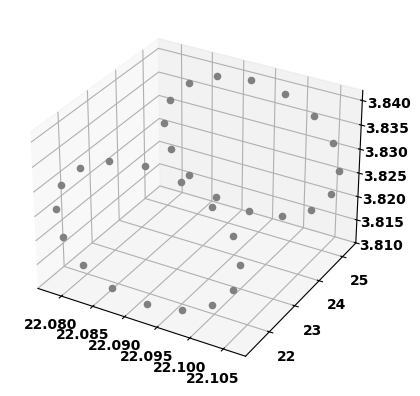

In [25]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

test_object = geom_dict['254']

for coords in test_object["vertices"]:
    ax.scatter(coords[0], coords[1], coords[2], color='grey')

We see the expected cylinder shape. From the chart, we can infer that the horizontal axis (Y) is the second coordinate since the range of this value goes from 22 - 25 as seen in the chart.

For ease of use, I shall create a function that plots automatically for a supplied vertex matrix.

In [3]:
def plot_vertices(vertices):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    
    for coords in vertices:
        ax.scatter(coords[0], coords[1], coords[2], color='grey')

    return ax

<Axes3D: >

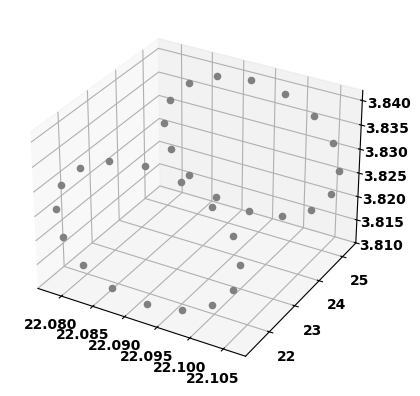

In [27]:
plot_vertices(test_object["vertices"])

<Axes3D: >

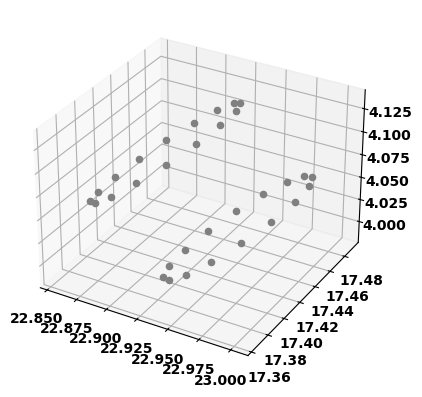

In [28]:
plot_vertices(geom_dict['3883']['vertices'])

Let's also see the transformation matrices of these objects.

In [29]:
test_object['matrix']

(1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0)

In [30]:
geom_dict['3883']['matrix']

(1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0)

Looks like the identity matrix, implying that the object is already in world coordinates.

Looks good for now. The next step will be to identify our dimensions. We're looking for the largest delta between min and max values for each of X, Y and Z.

In [31]:
test_object['vertices']

array([[22.10213519, 21.38393059,  3.81610051],
       [22.10517001, 21.38393059,  3.82064243],
       [22.1062357 , 21.38393059,  3.826     ],
       [22.1062357 , 25.29892148,  3.826     ],
       [22.10517001, 25.29892148,  3.82064243],
       [22.10213519, 25.29892148,  3.81610051],
       [22.09759326, 21.38393059,  3.81306569],
       [22.09759326, 25.29892148,  3.81306569],
       [22.0922357 , 21.38393059,  3.812     ],
       [22.0922357 , 25.29892148,  3.812     ],
       [22.08687813, 21.38393059,  3.81306569],
       [22.08687813, 25.29892148,  3.81306569],
       [22.0823362 , 21.38393059,  3.81610051],
       [22.0823362 , 25.29892148,  3.81610051],
       [22.07930138, 21.38393059,  3.82064243],
       [22.07930138, 25.29892148,  3.82064243],
       [22.0782357 , 21.38393059,  3.826     ],
       [22.07930138, 25.29892148,  3.83135757],
       [22.0782357 , 25.29892148,  3.826     ],
       [22.0823362 , 25.29892148,  3.83589949],
       [22.07930138, 21.38393059,  3.831

In [32]:
test_max_values = np.max(test_object['vertices'], axis=0)
test_max_values

array([22.1062357 , 25.29892148,  3.84      ])

In [33]:
test_min_values = np.min(test_object['vertices'], axis=0)
test_min_values

array([22.0782357 , 21.38393059,  3.812     ])

In [34]:
test_deltas = test_max_values - test_min_values
test_deltas

array([0.028     , 3.91499089, 0.028     ])

We observe that our longest axis is the Y dimension, which we observed from the chart earlier. However, this method assumes that our object is aligned to an axis. If the pipe is at an angle, the dimension measurement might be off. We need to keep this in mind while traversing through the elements in the model.

Just out of curiosity, lets see what multiple pipes look like on the chart.

<Axes3D: >

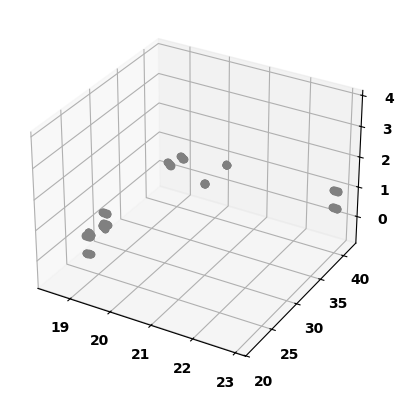

In [35]:
test_objects = ['401', '518', '637', '752', '1978']

vertices = geom_dict['254']["vertices"]

for obj in test_objects:
    vertices = np.append(vertices, geom_dict[obj]["vertices"], axis=0)

plot_vertices(vertices)

We don't appear to be getting anything useful for this chart. Oh well.

## Building the Transformation Matrix

As mentioned above, our goal is to create a new shape using basic geometry to mimic the original shape. This means, we need to calculate a transformation matrix for our basic shape such that it aligns itself nicely in space, matching where the original object was.

The Transformation Matrix is a 4x4 matrix that contains the translation, rotation and scale factors needed to position an object in 3D space. The matrix consists of a 3x3 matrix in the top left corner that represents the combined rotation and scale factors to be applied. The top right 3x1 vector is that of the translation vactor and the bottom 1x4 row is usually set to [0,0,0,1].

This video really helped me understand why the matrix is 4x4 dimensions https://www.youtube.com/watch?v=Do_vEjd6gF0.

We can find the translation vector through basic geometry- this should just be the centroid of the object. To align with this, our basic shape should also be centered about the origin (i.e. the centroid of our basic cylinder should be 0,0,0)

The centroid of our test object is -->

In [36]:
test_object_centroid = np.min(test_object['vertices'], axis=0) + (np.max(test_object['vertices'], axis=0) - np.min(test_object['vertices'], axis=0))/2
test_object_centroid

array([22.0922357 , 23.34142604,  3.826     ])

This seems to align with our previously observed min and max values. Of course, this vector needs to be transposed from 1x3 dimensionality to 3x1.

Note, we cannot simply use the `np.mean()` here since there may be a skew in the number of vertices on either side of the pipe. If one side has more vertices than the other, our centroid will be pulled to the side with more number of vertices. The diagram below explains this better. Hence we must use the tried and true line equation to find the midpoint of our object.

![Cannot simply calculate the mean](../img/calculation-of-centroid-mean.png)

Note, its unliekly that these skewed pipes exist in a model- I have yet to see one. However, its important to keep in mind, and now it won't be a problem even if we do eventually run into one of these pipes.

Calculating the rotation and scale will be a little more involved. Let's start with the rotation.

One suggestion provided by Gemini is to use Principal Component Analysis (PCA) to find the covariance matrix of our data- then the eigenvectors and values will give us the rotation and scale values respectively. In essence, PCA allows us to find the directions of highest variance in our data, enabling a reduction of dimensionality by grouping these data points. In our case, this will be used to find the local axes of our shape- enabling further derivation of the rotation matrix.

That was a mouthful, and I'm not even sure if I fully understand it. Let's work through some EDA.

In [37]:
test_vertices = test_object['vertices']

<Axes3D: >

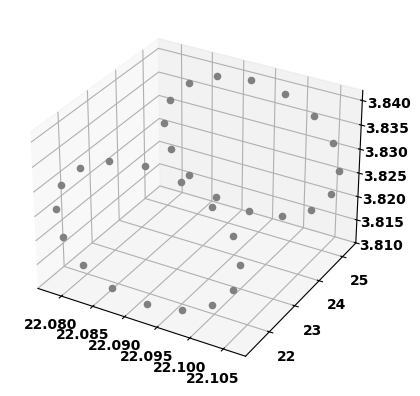

In [38]:
plot_vertices(test_vertices)

In [39]:
min_y = np.min(test_vertices, axis=0)[1]
min_y

np.float64(21.3839305891755)

In [40]:
max_y = np.max(test_vertices, axis=0)[1]
max_y

np.float64(25.29892148237586)

The mthod hints at finding a covariance matrix. This will allow us to measure the spread of our data along each of the axes. Let's see what we get. First, we should center our data.

In [41]:
centered_test_vertices = test_vertices - test_object_centroid
centered_test_vertices

array([[ 0.00989949, -1.95749545, -0.00989949],
       [ 0.01293431, -1.95749545, -0.00535757],
       [ 0.014     , -1.95749545,  0.        ],
       [ 0.014     ,  1.95749545,  0.        ],
       [ 0.01293431,  1.95749545, -0.00535757],
       [ 0.00989949,  1.95749545, -0.00989949],
       [ 0.00535757, -1.95749545, -0.01293431],
       [ 0.00535757,  1.95749545, -0.01293431],
       [ 0.        , -1.95749545, -0.014     ],
       [ 0.        ,  1.95749545, -0.014     ],
       [-0.00535757, -1.95749545, -0.01293431],
       [-0.00535757,  1.95749545, -0.01293431],
       [-0.00989949, -1.95749545, -0.00989949],
       [-0.00989949,  1.95749545, -0.00989949],
       [-0.01293431, -1.95749545, -0.00535757],
       [-0.01293431,  1.95749545, -0.00535757],
       [-0.014     , -1.95749545,  0.        ],
       [-0.01293431,  1.95749545,  0.00535757],
       [-0.014     ,  1.95749545,  0.        ],
       [-0.00989949,  1.95749545,  0.00989949],
       [-0.01293431, -1.95749545,  0.005

Now, the covariance matrix looks as follows.

In [42]:
test_cov = np.cov(centered_test_vertices, rowvar=False)
test_cov

array([[1.01161290e-04, 2.15492633e-19, 1.06840279e-21],
       [2.15492633e-19, 3.95539450e+00, 3.28369472e-20],
       [1.06840279e-21, 3.28369472e-20, 1.01161290e-04]])

We observe small covariances, and reasonably sized variances. This matrix should theoretically measure the deviance of each of our variables along each axis. So theoretically speaking, we'd observe different values if the pipe were not aligned to an axis (like in the current case). Let's try the same operation on a pipe that we know to be not aligned to the X,Y,Z axes. We observed this pipe while testing the plotting function earlier - with key `3883` in the geom_dict. 

<Axes3D: >

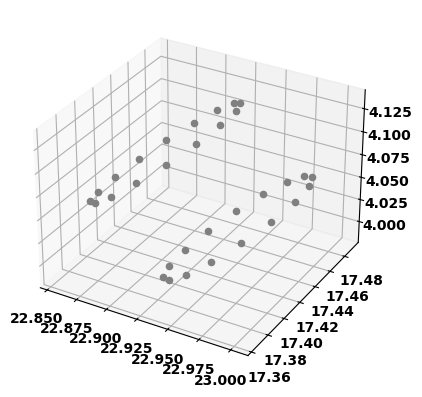

In [43]:
plot_vertices(geom_dict['3883']['vertices'])

Let's see what the covariance matrix looks like for this pipe.

In [44]:
test_non_aligned_vertices = geom_dict['3883']['vertices']
centroid_na_verts = np.min(test_non_aligned_vertices, axis=0) + (np.max(test_non_aligned_vertices, axis=0) - np.min(test_non_aligned_vertices, axis=0))/2
test_na_verts = test_non_aligned_vertices - centroid_na_verts

test_non_aligned_cov = np.cov(test_na_verts, rowvar=False)
test_non_aligned_cov

array([[ 1.91518600e-03, -3.51179965e-24,  1.00943033e-04],
       [-3.51179965e-24,  2.01612903e-03, -1.61981257e-18],
       [ 1.00943033e-04, -1.61981257e-18,  1.91518600e-03]])

We observe some non-negligible values in the covariance this time, specifically between the X and Z axes. That said, these results may be a little skewed since it looks like the pipe itself is small. Let's see if we can find a bigger pipe. I'll try going through them randomly, and if we cannot find one then we'll resort to a better approach.

In [45]:
geom_dict.keys()

dict_keys(['254', '401', '518', '637', '752', '1978', '2096', '3301', '3418', '3533', '3649', '3766', '3883', '3998', '4279', '4394', '4509', '4624', '4739', '5026', '5141', '7017', '7295', '7410', '7769', '7886', '8005', '8323', '8438', '12015', '12130', '12246', '12361', '12476', '18114', '18229', '18344', '24608', '33311', '37294', '37730', '39050', '40832', '41019', '41209', '41399', '43298', '43488', '43678', '43875', '44063', '44253', '44443', '44640', '44828', '45018', '45208', '45405', '45593', '45783', '45973', '46170', '46358', '46548', '46738', '46935', '47123', '47313', '47503', '47700', '47888', '48078', '48268', '48465', '48653', '48843', '49033', '49230', '49417', '49607', '49797', '49994', '50182', '50372', '50562', '50759', '50947', '51137', '51327', '51524', '51712', '51902', '52092', '52289', '52476', '52666', '52856', '53053', '53240', '53430', '53620', '58985', '59172', '59362', '59552', '59891', '60081', '60271', '60468', '60655', '60845', '61035', '61232', '61419

<Axes3D: >

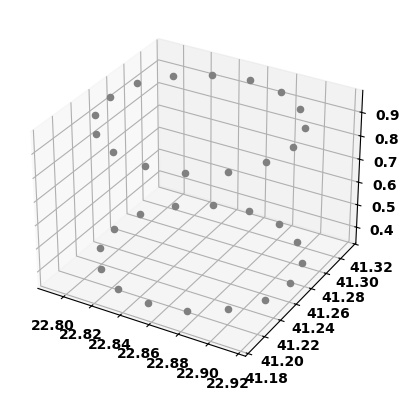

In [46]:
plot_vertices(geom_dict['1978']['vertices'])

<Axes3D: >

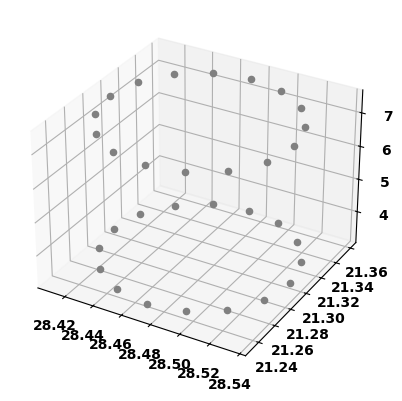

In [47]:
plot_vertices(geom_dict['4279']['vertices'])

<Axes3D: >

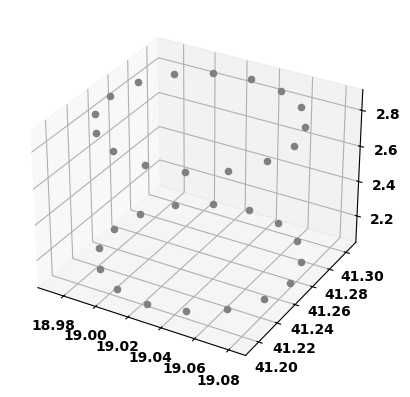

In [48]:
plot_vertices(geom_dict['8323']['vertices'])

<Axes3D: >

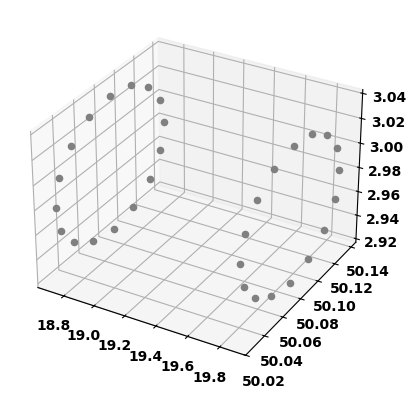

In [49]:
plot_vertices(geom_dict['12130']['vertices'])

<Axes3D: >

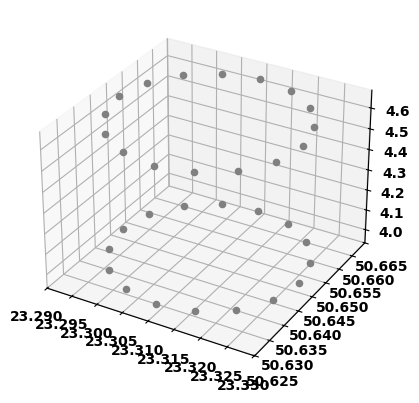

In [50]:
plot_vertices(geom_dict['39050']['vertices'])

<Axes3D: >

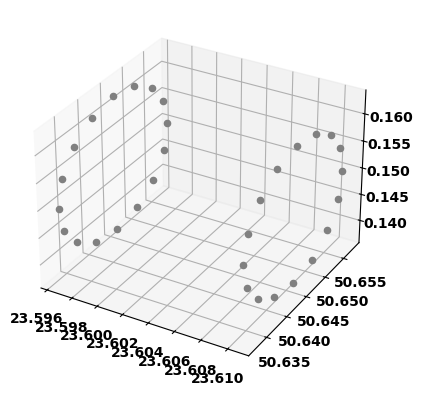

In [51]:
plot_vertices(geom_dict['44063']['vertices'])

<Axes3D: >

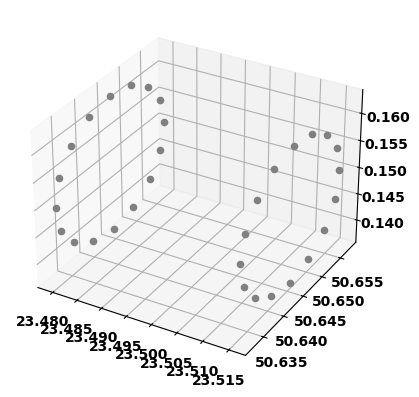

In [52]:
plot_vertices(geom_dict['44253']['vertices'])

OK. Doesn't seem to be playing nice. Let's open Bonsai and see if we can locate one of these pipes.

<Axes3D: >

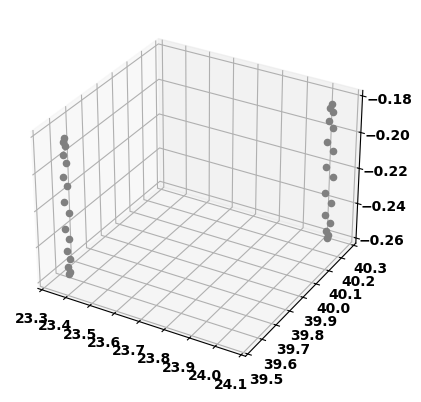

In [53]:
plot_vertices(geom_dict['1719047']['vertices'])

<Axes3D: >

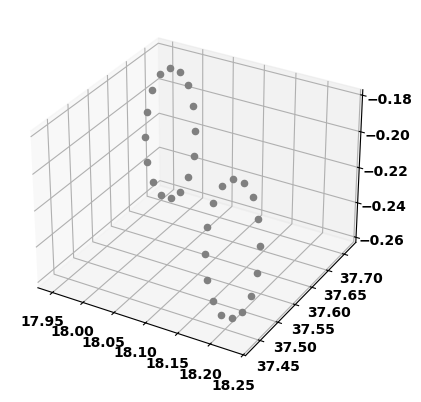

In [54]:
plot_vertices(geom_dict['4495075']['vertices'])

Looks like we have a few options to work with. For reference, the mesh_name in the simple layout window gave us the link to our geometry. Let's see what the covariance matrix looks like for these options.

In [55]:
test_non_aligned_vertices = geom_dict['1719047']['vertices']
centroid_na_verts = np.min(test_non_aligned_vertices, axis=0) + (np.max(test_non_aligned_vertices, axis=0) - np.min(test_non_aligned_vertices, axis=0))/2
test_na_verts = test_non_aligned_vertices - centroid_na_verts

test_non_aligned_cov = np.cov(test_na_verts, rowvar=False)
test_non_aligned_cov

array([[1.17765857e-01, 1.17040051e-01, 3.75342877e-20],
       [1.17040051e-01, 1.17765857e-01, 3.60459555e-20],
       [3.75342877e-20, 3.60459555e-20, 7.25806452e-04]])

In [56]:
test_non_aligned_vertices = geom_dict['4495075']['vertices']
centroid_na_verts = np.min(test_non_aligned_vertices, axis=0) + (np.max(test_non_aligned_vertices, axis=0) - np.min(test_non_aligned_vertices, axis=0))/2
test_na_verts = test_non_aligned_vertices - centroid_na_verts

test_non_aligned_cov = np.cov(test_na_verts, rowvar=False)
test_non_aligned_cov

array([[ 1.43408740e-02, -1.36150675e-02, -1.87908733e-20],
       [-1.36150675e-02,  1.43408740e-02, -1.58662865e-20],
       [-1.87908733e-20, -1.58662865e-20,  7.25806452e-04]])

We observe similar covariance values between Y and X like before, however we do note that the sign is switched in either case. This implies a negative correlation in the second and positive in the first- the magnitude seems to align with each other.

We infer from this that as the x coordinate increases, the y coordinate also appears to increase. This is not entirely apparent from the data, but we do see that the pipe is angled in the X,Y plane- corresponding to the non zero elements of the covariance matrix.

The next step is to find the eigenvectors and eigenvalues of the matrix. The eigenvectors of a matrix are the vectors in a linear transformation that do not change their direction after the transformation is applied- i.e. the axes of rotation of our shape. This should help us identify the exact rotation needed to transform our unit cylinder into the orientation needed.

The eigenvectors of our test non aligned pipes are as follows.

In [57]:
eg_values, eg_vectors = np.linalg.eigh(test_non_aligned_cov)
eg_vectors

array([[-7.07106781e-01,  0.00000000e+00,  7.07106781e-01],
       [-7.07106781e-01, -1.38015278e-18, -7.07106781e-01],
       [-9.75915393e-19,  1.00000000e+00, -9.75915393e-19]])

In [58]:
eg_values

array([0.00072581, 0.00072581, 0.02795594])

We need to sort our eignenvectors in descending order based on the eigenvalues. This will give us the longest direction. A good side effect we notice is that our 2 remaining eigenvalues are the same- this is to be expected since we're dealing with a cylinder.

Let's try this out with our earlier test pipe. This one is aligned to one of the axes, so we should expect our eigenvectors to be the unit vectors? Let's see.

In [59]:
test_eg_values, test_eg_vectors = np.linalg.eigh(test_cov)
test_eg_vectors = np.round(test_eg_vectors, 4)
test_eg_vectors

array([[ 1.,  0., -0.],
       [ 0., -0.,  1.],
       [ 0., -1., -0.]])

In [60]:
test_eg_values

array([1.0116129e-04, 1.0116129e-04, 3.9553945e+00])

We see from the array of eigenvalues that the third value is largest. This means that the largest covariance was observed in the direction of the vector in the third position. Looking at the eigenvectors array, we see that the vector in the third location is our Y vector ([0,1,0]).

As a reminder, this is what our pipe looks like.

<Axes3D: >

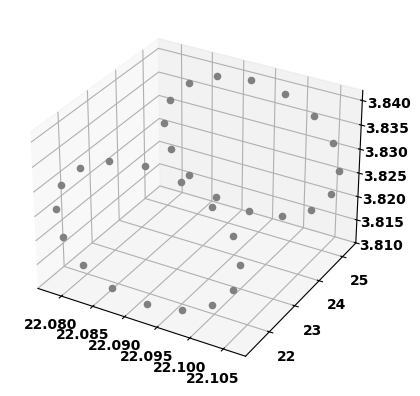

In [61]:
plot_vertices(test_vertices)

This aligns with what we observe, so I'm happy with this. This also means that in the previous non aligned pipe example, our largest direction of covariance is in the direction of the third vector, which is [-0.71, -0.71, 0]; which as a reminder, looks like this.

<Axes3D: >

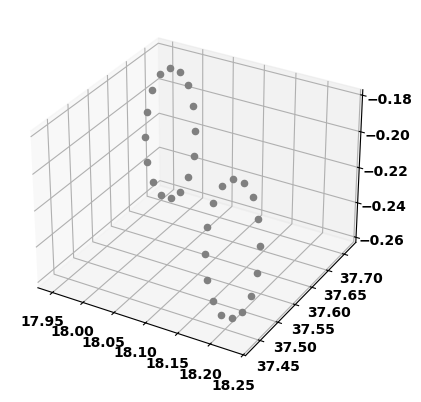

In [62]:
plot_vertices(geom_dict['4495075']['vertices'])

So the eigenvectors and values appear to be working as intended. Now, how do we get the transformation matrix from this? Well, we still need the scale of the transformation. Let's project our original points onto the new axes and measure the deviance. In the case of our non aligned pipe above, this is what needs to be done -->

In [63]:
projected_verts = test_na_verts @ eg_vectors
projected_verts

array([[ 3.46454825e-02,  1.43506287e-02, -1.64567063e-01],
       [ 3.46454825e-02, -1.43506287e-02, -1.64567063e-01],
       [ 3.75000000e-02, -1.24006703e-19, -1.64567063e-01],
       [ 3.46454825e-02, -1.43506287e-02,  1.64567063e-01],
       [ 3.75000000e-02,  1.97200357e-19,  1.64567063e-01],
       [ 2.65165043e-02, -2.65165043e-02, -1.64567063e-01],
       [ 1.43506287e-02, -3.46454825e-02,  1.64567063e-01],
       [ 2.65165043e-02, -2.65165043e-02,  1.64567063e-01],
       [ 1.43506287e-02, -3.46454825e-02, -1.64567063e-01],
       [ 1.07367999e-15, -3.75000000e-02, -1.64567063e-01],
       [-1.43506287e-02, -3.46454825e-02,  1.64567063e-01],
       [ 3.95068907e-15, -3.75000000e-02,  1.64567063e-01],
       [-2.65165043e-02, -2.65165043e-02,  1.64567063e-01],
       [-1.43506287e-02, -3.46454825e-02, -1.64567063e-01],
       [-3.46454825e-02, -1.43506287e-02,  1.64567063e-01],
       [-2.65165043e-02, -2.65165043e-02, -1.64567063e-01],
       [-3.75000000e-02,  1.24006703e-19

<Axes3D: >

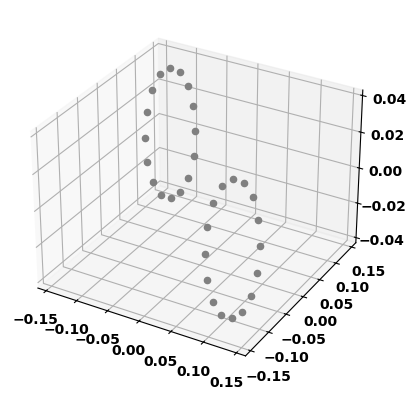

In [64]:
plot_vertices(test_na_verts)

In [65]:
test_non_aligned_vertices = geom_dict['4495075']['vertices']

centroid_na_verts = np.min(test_non_aligned_vertices, axis=0) + (np.max(test_non_aligned_vertices, axis=0) - np.min(test_non_aligned_vertices, axis=0))/2
centered_na_verts = test_non_aligned_vertices - centroid_na_verts
centered_na_verts

array([[-0.14086454,  0.09186843,  0.01435063],
       [-0.14086454,  0.09186843, -0.01435063],
       [-0.14288299,  0.08984998,  0.        ],
       [ 0.09186843, -0.14086454, -0.01435063],
       [ 0.08984998, -0.14288299,  0.        ],
       [-0.13511649,  0.09761649, -0.0265165 ],
       [ 0.10621906, -0.12651391, -0.03464548],
       [ 0.09761649, -0.13511649, -0.0265165 ],
       [-0.12651391,  0.10621906, -0.03464548],
       [-0.11636649,  0.11636649, -0.0375    ],
       [ 0.12651391, -0.10621906, -0.03464548],
       [ 0.11636649, -0.11636649, -0.0375    ],
       [ 0.13511649, -0.09761649, -0.0265165 ],
       [-0.10621906,  0.12651391, -0.03464548],
       [ 0.14086454, -0.09186843, -0.01435063],
       [-0.09761649,  0.13511649, -0.0265165 ],
       [ 0.14288299, -0.08984998,  0.        ],
       [-0.09186843,  0.14086454, -0.01435063],
       [-0.08984998,  0.14288299,  0.        ],
       [-0.09186843,  0.14086454,  0.01435063],
       [ 0.14086454, -0.09186843,  0.014

<Axes3D: >

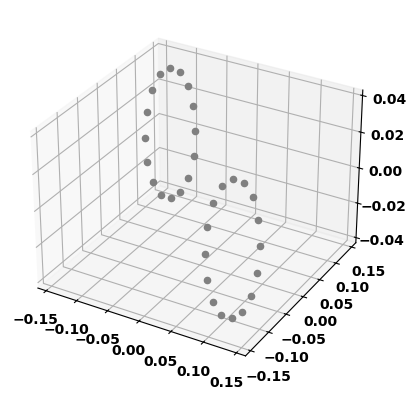

In [66]:
plot_vertices(centered_na_verts)

In [67]:
cov_na_verts = np.cov(centered_na_verts, rowvar=False)
cov_na_verts

array([[ 1.43408740e-02, -1.36150675e-02, -1.87908733e-20],
       [-1.36150675e-02,  1.43408740e-02, -1.58662865e-20],
       [-1.87908733e-20, -1.58662865e-20,  7.25806452e-04]])

In [68]:
na_eg_values, na_eg_vectors = np.linalg.eigh(cov_na_verts)
np.round(na_eg_vectors, 4)

array([[-0.7071,  0.    ,  0.7071],
       [-0.7071, -0.    , -0.7071],
       [-0.    ,  1.    , -0.    ]])

In [69]:
np.round(na_eg_values, 4)

array([0.0007, 0.0007, 0.028 ])

In [70]:
np.argsort( - np.round(na_eg_values, 4))

array([2, 0, 1])

In theory, the eigenvalues corresponding to the 2 smaller axes will be the same (since we're dealing with a circular cross section). This means, we should check to see if any 2 are the same, and by default that would mean our length axis is the one remaining.

In [71]:
na_eg_values = np.round(na_eg_values, 4)
na_eg_values

array([0.0007, 0.0007, 0.028 ])

In [72]:
test_set = set()
test_set.add(na_eg_values[0])
length_axis = None
minor_axis_1 = None
minor_axis_2 = None

if na_eg_values[1] in test_set: 
    length_axis = 2

elif na_eg_values[2] in test_set:
    length_axis = 1

else:
    length_axis = 0

print(length_axis)

2


In [73]:
if na_eg_values[0] == na_eg_values[1]: 
    length_axis = 2
    minor_axis_1 = 0
    minor_axis_2 = 1

elif na_eg_values[0] == na_eg_values[2]:
    length_axis = 1
    minor_axis_1 = 0
    minor_axis_2 = 2

elif na_eg_values[2] == na_eg_values[3]:
    length_axis = 0
    minor_axis_1 = 2
    minor_axis_2 = 1

else:
    length_axis = np.nan
    minor_axis_1 = np.nan
    minor_axis_2 = np.nan

print(length_axis)

2


Now that we have our length axis, we can order our eigenvectors according to this.

In [74]:
reorder_na_eg_vectors = na_eg_vectors[:, [minor_axis_1, length_axis, minor_axis_2]]
reorder_na_eg_vectors

array([[-7.07106781e-01,  7.07106781e-01,  0.00000000e+00],
       [-7.07106781e-01, -7.07106781e-01, -1.38015278e-18],
       [-9.75915393e-19, -9.75915393e-19,  1.00000000e+00]])

This gives us the rotation matrix for our unit pipe. Now, let's find the projection of our original vertices onto this new basis. We do this by applying a cross product between our original vertices and eigenvector matrix.

In [75]:
projected_verts = centered_na_verts @ reorder_na_eg_vectors
projected_verts

array([[ 3.46454825e-02, -1.64567063e-01,  1.43506287e-02],
       [ 3.46454825e-02, -1.64567063e-01, -1.43506287e-02],
       [ 3.75000000e-02, -1.64567063e-01, -1.24006703e-19],
       [ 3.46454825e-02,  1.64567063e-01, -1.43506287e-02],
       [ 3.75000000e-02,  1.64567063e-01,  1.97200357e-19],
       [ 2.65165043e-02, -1.64567063e-01, -2.65165043e-02],
       [ 1.43506287e-02,  1.64567063e-01, -3.46454825e-02],
       [ 2.65165043e-02,  1.64567063e-01, -2.65165043e-02],
       [ 1.43506287e-02, -1.64567063e-01, -3.46454825e-02],
       [ 1.07367999e-15, -1.64567063e-01, -3.75000000e-02],
       [-1.43506287e-02,  1.64567063e-01, -3.46454825e-02],
       [ 3.95068907e-15,  1.64567063e-01, -3.75000000e-02],
       [-2.65165043e-02,  1.64567063e-01, -2.65165043e-02],
       [-1.43506287e-02, -1.64567063e-01, -3.46454825e-02],
       [-3.46454825e-02,  1.64567063e-01, -1.43506287e-02],
       [-2.65165043e-02, -1.64567063e-01, -2.65165043e-02],
       [-3.75000000e-02,  1.64567063e-01

<Axes3D: >

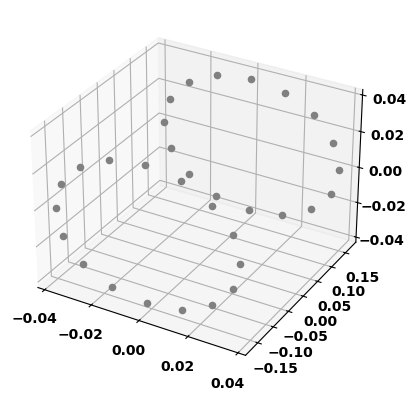

In [76]:
plot_vertices(projected_verts)

This looks like what we should be expecting. To clarify, we have essentially rotated our origin to align with the center axis of our pipe, essentially acting like a change of basis. This way, we can truly find the scale of this pipe in either axis direction. Let's do that now. Since our pipe is centered, the max value in all axes will give us the scale for that axis.

In [77]:
scale_vector = np.max(projected_verts, axis=0)
scale_vector

array([0.0375    , 0.16456706, 0.0375    ])

Perfect. Now, we need to convert our scale vector into a matrix transform. This is because the order of operations matter. We first need to rotate our input shape, then scale it. If we rearrange the operations, we get a different result. Therefore, the exact equation for the final transformation is -->

T = R @ S

Converting the scale vector to a scale matrix, this is what we observe.

In [78]:
scale_matrix = np.diag(scale_vector)
scale_matrix

array([[0.0375    , 0.        , 0.        ],
       [0.        , 0.16456706, 0.        ],
       [0.        , 0.        , 0.0375    ]])

Now, matrix multiplying the 2 gives us the combined rotation / scale matrix.

In [79]:
R_S = reorder_na_eg_vectors @ scale_matrix
R_S

array([[-2.65165043e-02,  1.16366486e-01,  0.00000000e+00],
       [-2.65165043e-02, -1.16366486e-01, -5.17557294e-20],
       [-3.65968272e-20, -1.60603530e-19,  3.75000000e-02]])

The remaining elements of the final transformation matrix consist of the translation vector (which in this case will just be the centroid which we calculated from earlier), and 0's and 1's.

In [80]:
T_matrix = np.eye(4,4)
T_matrix

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [81]:
T_matrix[:3, :3] = R_S
T_matrix

array([[-2.65165043e-02,  1.16366486e-01,  0.00000000e+00,
         0.00000000e+00],
       [-2.65165043e-02, -1.16366486e-01, -5.17557294e-20,
         0.00000000e+00],
       [-3.65968272e-20, -1.60603530e-19,  3.75000000e-02,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

Let's add the centroid into the mix -->

In [82]:
centroid_na_verts

array([18.08966297, 37.57346702, -0.22      ])

In [83]:
T_matrix[:3, 3] = centroid_na_verts
T_matrix

array([[-2.65165043e-02,  1.16366486e-01,  0.00000000e+00,
         1.80896630e+01],
       [-2.65165043e-02, -1.16366486e-01, -5.17557294e-20,
         3.75734670e+01],
       [-3.65968272e-20, -1.60603530e-19,  3.75000000e-02,
        -2.20000000e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

Hence, now we have our final transformation matrix.

## Creating a Unit Cylinder

Now that we have our transformation matrix set up, all we need to do is create a unit cylinder and apply this transformation matix to each of its coordinates. Let's create the unit cylinder. Since we're working with centered data, we should create a cylinder with total length 2, and radius = 1 (not diameter). This way, when we multiply the vertices of this object by our transformation matrix, its essentially a case of multiplying 1 by the new scale.

We created a basic unit pipe in Blender.

![Simple Unit Pipe](../img/simple_pipe.png)

Let's load it up and get the vertices and faces from it. Really, all we need are the vertices since the faces will simply reference the transformed vertex array. We have previously used pymeshlab to extract this information.

In [84]:
import pymeshlab

First, we need to create a new meshset to import the sample pipe we have just created.

In [85]:
ms = pymeshlab.MeshSet()
ms.load_new_mesh('data/simple_pipe.obj')

Now, we can get the vertex matrix like so.

In [86]:
m = ms.current_mesh()
v_matrix = m.vertex_matrix()

v_matrix

array([[ 0.      ,  1.      ,  1.      ],
       [ 0.      , -1.      ,  1.      ],
       [ 0.19509 ,  1.      ,  0.980785],
       [ 0.19509 , -1.      ,  0.980785],
       [ 0.382683,  1.      ,  0.92388 ],
       [ 0.382683, -1.      ,  0.923879],
       [ 0.55557 ,  1.      ,  0.83147 ],
       [ 0.55557 , -1.      ,  0.83147 ],
       [ 0.707107,  1.      ,  0.707107],
       [ 0.707107, -1.      ,  0.707107],
       [ 0.83147 ,  1.      ,  0.55557 ],
       [ 0.83147 , -1.      ,  0.55557 ],
       [ 0.92388 ,  1.      ,  0.382683],
       [ 0.92388 , -1.      ,  0.382683],
       [ 0.980785,  1.      ,  0.19509 ],
       [ 0.980785, -1.      ,  0.19509 ],
       [ 1.      ,  1.      ,  0.      ],
       [ 1.      , -1.      , -0.      ],
       [ 0.980785,  1.      , -0.19509 ],
       [ 0.980785, -1.      , -0.19509 ],
       [ 0.92388 ,  1.      , -0.382683],
       [ 0.92388 , -1.      , -0.382683],
       [ 0.83147 ,  1.      , -0.55557 ],
       [ 0.83147 , -1.      , -0.5

Let's see what this pipe looks like using our `plot_vertices()` function.

<Axes3D: >

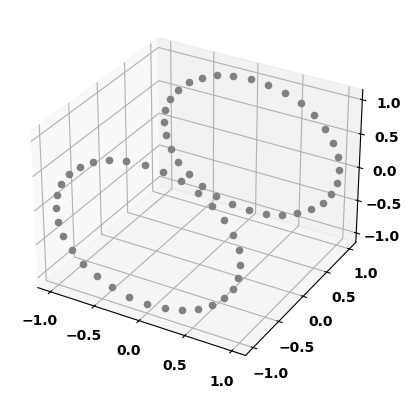

In [87]:
plot_vertices(v_matrix)

While this is indeed too detailed, we shall utilize this pipe for testing purposes (since we should be immediately able to tell which pipe is our original and which one is our sample). Later on, we'll switch this out for one that is less defined.

First, let's multiply our `v_matrix` by the transformation matrix to see what we get. We also need to append an extra column to the end to make the matrix math work out. This column will be entirely 1's

In [88]:
v_matrix_4 = np.c_[v_matrix, np.ones(v_matrix.shape[0])]
v_matrix_4

array([[ 0.      ,  1.      ,  1.      ,  1.      ],
       [ 0.      , -1.      ,  1.      ,  1.      ],
       [ 0.19509 ,  1.      ,  0.980785,  1.      ],
       [ 0.19509 , -1.      ,  0.980785,  1.      ],
       [ 0.382683,  1.      ,  0.92388 ,  1.      ],
       [ 0.382683, -1.      ,  0.923879,  1.      ],
       [ 0.55557 ,  1.      ,  0.83147 ,  1.      ],
       [ 0.55557 , -1.      ,  0.83147 ,  1.      ],
       [ 0.707107,  1.      ,  0.707107,  1.      ],
       [ 0.707107, -1.      ,  0.707107,  1.      ],
       [ 0.83147 ,  1.      ,  0.55557 ,  1.      ],
       [ 0.83147 , -1.      ,  0.55557 ,  1.      ],
       [ 0.92388 ,  1.      ,  0.382683,  1.      ],
       [ 0.92388 , -1.      ,  0.382683,  1.      ],
       [ 0.980785,  1.      ,  0.19509 ,  1.      ],
       [ 0.980785, -1.      ,  0.19509 ,  1.      ],
       [ 1.      ,  1.      ,  0.      ,  1.      ],
       [ 1.      , -1.      , -0.      ,  1.      ],
       [ 0.980785,  1.      , -0.19509 ,  1.  

Now, performing the matrix multiplication with the transformation matrix, this is what we get.

In [89]:
v_hat = T_matrix @ np.transpose(v_matrix_4)
np.transpose(v_hat)

array([[18.20602946, 37.45710053, -0.1825    ,  1.        ],
       [17.97329648, 37.68983351, -0.1825    ,  1.        ],
       [18.20085635, 37.45192743, -0.18322056,  1.        ],
       [17.96812338, 37.6846604 , -0.18322056,  1.        ],
       [18.19588204, 37.44695312, -0.1853545 ,  1.        ],
       [17.96314907, 37.67968609, -0.18535454,  1.        ],
       [18.19129768, 37.44236876, -0.18881987,  1.        ],
       [17.95856471, 37.67510173, -0.18881987,  1.        ],
       [18.18727945, 37.43835053, -0.19348349,  1.        ],
       [17.95454648, 37.6710835 , -0.19348349,  1.        ],
       [18.18398178, 37.43505286, -0.19916612,  1.        ],
       [17.95124881, 37.66778583, -0.19916612,  1.        ],
       [18.18153139, 37.43260247, -0.20564939,  1.        ],
       [17.94879842, 37.66533544, -0.20564939,  1.        ],
       [18.18002247, 37.43109355, -0.21268413,  1.        ],
       [17.9472895 , 37.66382652, -0.21268413,  1.        ],
       [18.17951295, 37.

In [90]:
v_transformed = np.transpose(v_hat)[:, :3]
v_transformed

array([[18.20602946, 37.45710053, -0.1825    ],
       [17.97329648, 37.68983351, -0.1825    ],
       [18.20085635, 37.45192743, -0.18322056],
       [17.96812338, 37.6846604 , -0.18322056],
       [18.19588204, 37.44695312, -0.1853545 ],
       [17.96314907, 37.67968609, -0.18535454],
       [18.19129768, 37.44236876, -0.18881987],
       [17.95856471, 37.67510173, -0.18881987],
       [18.18727945, 37.43835053, -0.19348349],
       [17.95454648, 37.6710835 , -0.19348349],
       [18.18398178, 37.43505286, -0.19916612],
       [17.95124881, 37.66778583, -0.19916612],
       [18.18153139, 37.43260247, -0.20564939],
       [17.94879842, 37.66533544, -0.20564939],
       [18.18002247, 37.43109355, -0.21268413],
       [17.9472895 , 37.66382652, -0.21268413],
       [18.17951295, 37.43058403, -0.22      ],
       [17.94677998, 37.663317  , -0.22      ],
       [18.18002247, 37.43109355, -0.22731588],
       [17.9472895 , 37.66382652, -0.22731588],
       [18.18153139, 37.43260247, -0.234

<Axes3D: >

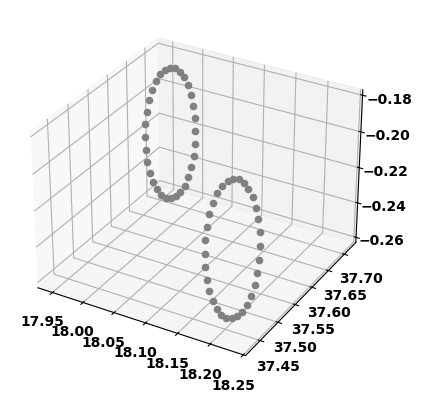

In [91]:
plot_vertices(v_transformed)

<Axes3D: >

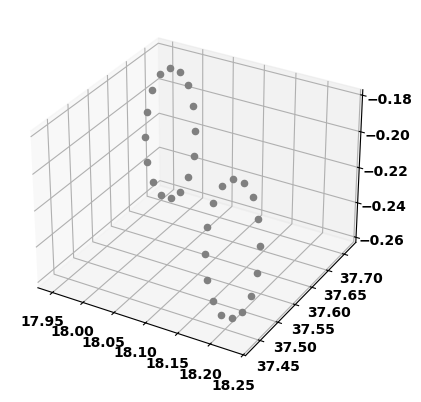

In [92]:
plot_vertices(geom_dict['4495075']['vertices'])

That looks pretty good, if I may say so myself. Our pipes appear to be aligned and with the same dimensions as the original. Let's try another example.

Before we function-ize the workflow, I'll go through the steps manually just to ensure that we understand what going on- since we did do quite a lot of steps. Let's work with this pipe.

<Axes3D: >

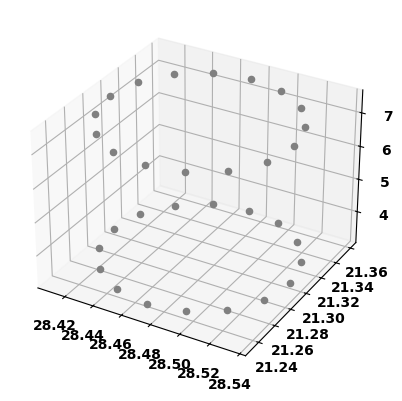

In [93]:
plot_vertices(geom_dict['4279']['vertices'])

In [94]:
test_pipe = geom_dict['4279']['vertices']
test_pipe

array([[28.41441432, 21.31990206,  3.32200008],
       [28.41441432, 21.27206663,  3.32200008],
       [28.40965679, 21.29598434,  3.32200009],
       [28.41442091, 21.27206663,  7.37750393],
       [28.40966338, 21.29598434,  7.37750393],
       [28.4279692 , 21.25179017,  7.3775039 ],
       [28.42796262, 21.25179017,  3.32200006],
       [28.44823908, 21.23824187,  3.32200002],
       [28.47216338, 21.23348434,  7.37750383],
       [28.44824566, 21.23824187,  7.37750387],
       [28.49608109, 21.23824187,  7.37750379],
       [28.47215679, 21.23348434,  3.32199998],
       [28.51635755, 21.25179017,  7.37750376],
       [28.49607451, 21.23824187,  3.32199995],
       [28.52990585, 21.27206663,  7.37750374],
       [28.51635097, 21.25179017,  3.32199991],
       [28.53466338, 21.29598434,  7.37750373],
       [28.52989926, 21.27206663,  3.32199989],
       [28.53465679, 21.29598434,  3.32199988],
       [28.52989926, 21.31990206,  3.32199989],
       [28.52990585, 21.31990206,  7.377

STEP 1: Center the vertices.

In [95]:
test_pipe_centroid = np.min(test_pipe, axis=0) + (np.max(test_pipe, axis=0) - np.min(test_pipe, axis=0))/2

centered_test_pipe = test_pipe - test_pipe_centroid
centered_test_pipe

array([[-5.77457622e-02,  2.39177145e-02, -2.02775183e+00],
       [-5.77457622e-02, -2.39177145e-02, -2.02775183e+00],
       [-6.25032915e-02,  0.00000000e+00, -2.02775182e+00],
       [-5.77391793e-02, -2.39177145e-02,  2.02775202e+00],
       [-6.24967085e-02,  0.00000000e+00,  2.02775203e+00],
       [-4.41908824e-02, -4.41941738e-02,  2.02775200e+00],
       [-4.41974653e-02, -4.41941738e-02, -2.02775185e+00],
       [-2.39210060e-02, -5.77424708e-02, -2.02775188e+00],
       [ 3.29145161e-06, -6.25000000e-02,  2.02775192e+00],
       [-2.39144231e-02, -5.77424708e-02,  2.02775196e+00],
       [ 2.39210060e-02, -5.77424708e-02,  2.02775188e+00],
       [-3.29145161e-06, -6.25000000e-02, -2.02775192e+00],
       [ 4.41974653e-02, -4.41941738e-02,  2.02775185e+00],
       [ 2.39144231e-02, -5.77424708e-02, -2.02775196e+00],
       [ 5.77457622e-02, -2.39177145e-02,  2.02775183e+00],
       [ 4.41908824e-02, -4.41941738e-02, -2.02775200e+00],
       [ 6.25032915e-02,  0.00000000e+00

<Axes3D: >

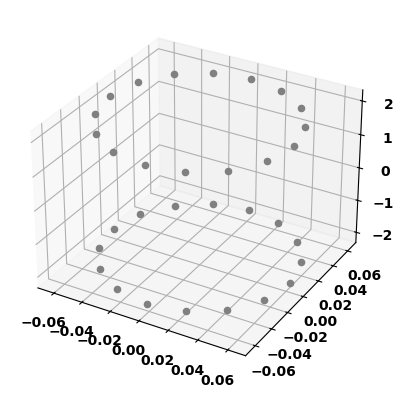

In [96]:
plot_vertices(centered_test_pipe)

STEP 2: Find the covariance matrix.

In [97]:
cov_matrix_test_pipe = np.cov(centered_test_pipe, rowvar=False)
cov_matrix_test_pipe

array([[ 2.01612904e-03, -6.14816795e-22,  6.88627304e-06],
       [-6.14816795e-22,  2.01612903e-03,  1.21617131e-18],
       [ 6.88627304e-06,  1.21617131e-18,  4.24441586e+00]])

STEP 3: Find the eigenvectors and values of the covariance matrix.

In [98]:
eg_val_test_pipe, eg_vec_test_pipe = np.linalg.eigh(cov_matrix_test_pipe)
eg_val_test_pipe

array([2.01612903e-03, 2.01612903e-03, 4.24441586e+00])

In [99]:
eg_vec_test_pipe

array([[ 2.72490014e-05,  1.00000000e+00, -1.62320231e-06],
       [ 1.00000000e+00, -2.72490014e-05,  0.00000000e+00],
       [-4.42308412e-11, -1.62320231e-06, -1.00000000e+00]])

STEP 4: Reorder the eigenvector matrix in the correct order. (X = minor axis_1, Y = length axis, Z = minor axis_2)

In [100]:
length_axis = None
minor_axis_1 = None
minor_axis_2 = None

if na_eg_values[0] == na_eg_values[1]: 
    length_axis = 2
    minor_axis_1 = 0
    minor_axis_2 = 1

elif na_eg_values[0] == na_eg_values[2]:
    length_axis = 1
    minor_axis_1 = 0
    minor_axis_2 = 2

elif na_eg_values[2] == na_eg_values[3]:
    length_axis = 0
    minor_axis_1 = 2
    minor_axis_2 = 1

else:
    length_axis = np.nan
    minor_axis_1 = np.nan
    minor_axis_2 = np.nan

eg_vec_test_pipe = eg_vec_test_pipe[:, [minor_axis_1, length_axis, minor_axis_2]]
eg_vec_test_pipe

array([[ 2.72490014e-05, -1.62320231e-06,  1.00000000e+00],
       [ 1.00000000e+00,  0.00000000e+00, -2.72490014e-05],
       [-4.42308412e-11, -1.00000000e+00, -1.62320231e-06]])

STEP 5: Project the original vertices onto the eigenvectors and find the scale in each direction.

In [101]:
projected_verts_test = centered_test_pipe @ eg_vec_test_pipe

scale_vector_test = np.max(projected_verts_test, axis = 0)
scale_vector_test

array([0.0625    , 2.02775192, 0.0625    ])

<Axes3D: >

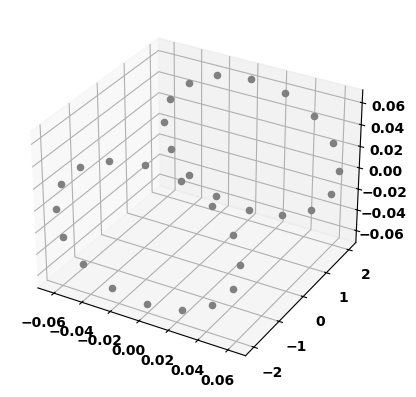

In [102]:
plot_vertices(projected_verts_test)

STEP 6: Create the final transformation matrix.

In [103]:
T_matrix_test = np.eye(4, 4)
T_matrix_test[:3, :3] = eg_vec_test_pipe @ np.diag(scale_vector_test)
T_matrix_test[:3, 3] = test_pipe_centroid
T_matrix_test

array([[ 1.70306259e-06, -3.29145161e-06,  6.25000000e-02,
         2.84721601e+01],
       [ 6.25000000e-02,  0.00000000e+00, -1.70306259e-06,
         2.12959843e+01],
       [-2.76442757e-12, -2.02775192e+00, -1.01450144e-07,
         5.34975191e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

STEP 7: Transform the unit pipe using the calculated transformation matrix

In [104]:
v_transformed_test = np.transpose(T_matrix_test @ np.transpose(v_matrix_4))[:,:3]
v_transformed_test

array([[28.53465679, 21.29598264,  3.32199988],
       [28.53466338, 21.29598264,  7.37750373],
       [28.53345619, 21.3081758 ,  3.32199989],
       [28.53346277, 21.3081758 ,  7.37750373],
       [28.52989995, 21.31990046,  3.32199989],
       [28.52990647, 21.31990046,  7.37750374],
       [28.52412461, 21.33070605,  3.3219999 ],
       [28.5241312 , 21.33070605,  7.37750375],
       [28.51635219, 21.34017733,  3.32199991],
       [28.51635877, 21.34017733,  7.37750376],
       [28.50688133, 21.34795027,  3.32199993],
       [28.50688792, 21.34795027,  7.37750378],
       [28.49607605, 21.35372619,  3.32199995],
       [28.49608264, 21.35372619,  7.37750379],
       [28.48435159, 21.35728307,  3.32199996],
       [28.48435817, 21.35728307,  7.37750381],
       [28.4721585 , 21.35848434,  3.32199998],
       [28.47216508, 21.35848434,  7.37750383],
       [28.45996534, 21.35728374,  3.322     ],
       [28.45997192, 21.35728374,  7.37750385],
       [28.44824068, 21.35372749,  3.322

<Axes3D: >

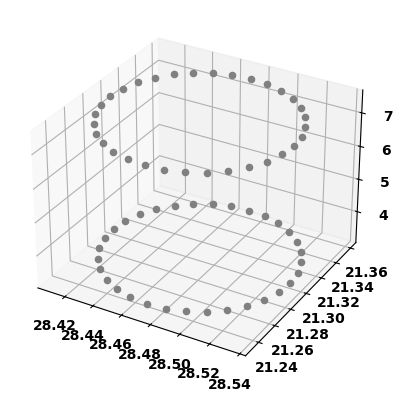

In [105]:
plot_vertices(v_transformed_test)

STEP 8: Confirm the shape looks the same as the original.

<Axes3D: >

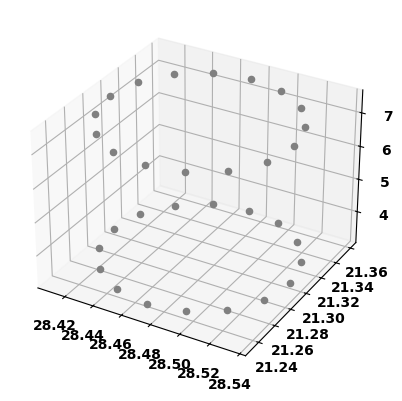

In [106]:
plot_vertices(test_pipe)

Phew. I was worried something would go wrong. But it looks like its working now. Let's function-ize this code.

In [107]:
def get_transformation_matrix(input_v):
    '''
    Given a vertex array, finds the transformation matrix required to rotate, scale, and translate a shape into that position. Works best for pipes.

    inputs:
        input_v: numpy array

    returns:
        transformation_matrix: numpy array 
    '''
    # Step 1: Center vertices
    centroid = np.min(input_v, axis=0) + (np.max(input_v, axis=0) - np.min(input_v, axis=0))/2
    centered_v = input_v - centroid

    # Step 2: Find covariance matrix
    cov_mat = np.cov(centered_v, rowvar=False)

    # Step 3: Find eigenvectors and values of the cov matrix
    eg_val, eg_vec = np.linalg.eigh(cov_mat)
    eg_val = np.round(eg_val, 4)

    # Step 4: Reorder eigenvector matrix to match length axis
    length_axis = None
    minor_axis_1 = None
    minor_axis_2 = None

    if eg_val[0] == eg_val[1]: 
        length_axis = 2
        minor_axis_1 = 0
        minor_axis_2 = 1

    elif eg_val[0] == eg_val[2]:
        length_axis = 1
        minor_axis_1 = 0
        minor_axis_2 = 2

    elif eg_val[1] == eg_val[2]:
        length_axis = 0
        minor_axis_1 = 2
        minor_axis_2 = 1

    else:
        length_axis = np.nan
        minor_axis_1 = np.nan
        minor_axis_2 = np.nan

    eg_vec = eg_vec[:, [minor_axis_1, length_axis, minor_axis_2]]

    # Step 5: Find scale vector by projecting original verts onto the eg_vectors
    projected_v = centered_v @ eg_vec

    scale_vec = np.max(projected_v, axis = 0)

    # Step 6: Find the final transformation matrix
    T_matrix = np.eye(4, 4)
    T_matrix[:3, :3] = eg_vec @ np.diag(scale_vec)
    T_matrix[:3, 3] = centroid

    # Return

    return T_matrix

And now lets run some more tests.

## Testing

Let's test some additional pipes in our set to ensure we have not missed anything.

In [108]:
geom_dict.keys()

dict_keys(['254', '401', '518', '637', '752', '1978', '2096', '3301', '3418', '3533', '3649', '3766', '3883', '3998', '4279', '4394', '4509', '4624', '4739', '5026', '5141', '7017', '7295', '7410', '7769', '7886', '8005', '8323', '8438', '12015', '12130', '12246', '12361', '12476', '18114', '18229', '18344', '24608', '33311', '37294', '37730', '39050', '40832', '41019', '41209', '41399', '43298', '43488', '43678', '43875', '44063', '44253', '44443', '44640', '44828', '45018', '45208', '45405', '45593', '45783', '45973', '46170', '46358', '46548', '46738', '46935', '47123', '47313', '47503', '47700', '47888', '48078', '48268', '48465', '48653', '48843', '49033', '49230', '49417', '49607', '49797', '49994', '50182', '50372', '50562', '50759', '50947', '51137', '51327', '51524', '51712', '51902', '52092', '52289', '52476', '52666', '52856', '53053', '53240', '53430', '53620', '58985', '59172', '59362', '59552', '59891', '60081', '60271', '60468', '60655', '60845', '61035', '61232', '61419

<Axes3D: >

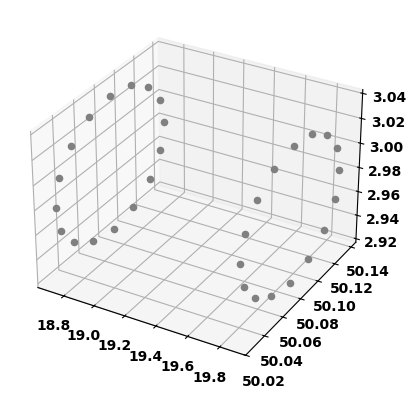

In [109]:
plot_vertices(geom_dict['12130']['vertices'])

In [110]:
input_v = geom_dict['12130']['vertices']

T_mat_input = get_transformation_matrix(input_v)
T_mat_input

array([[ 0.00000000e+00,  5.81193428e-01,  0.00000000e+00,
         1.92921253e+01],
       [ 5.49981223e-02,  0.00000000e+00,  3.21355237e-04,
         5.00828888e+01],
       [-3.21355237e-04,  0.00000000e+00,  5.49981223e-02,
         2.98000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

<Axes3D: >

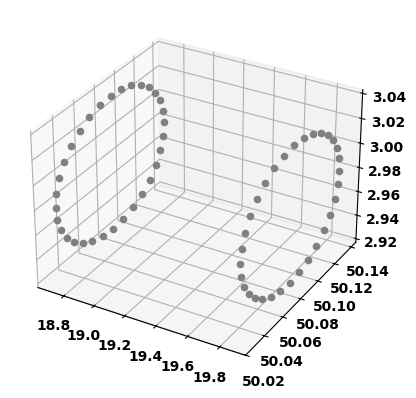

In [111]:
v_transformed = np.transpose(T_mat_input @ np.transpose(v_matrix_4))[:, :3]
plot_vertices(v_transformed)

Already, we found one error. The eigenvalue test was testing for eigenvalue in index 3 when our last index is 2. This has been changed.

Test 2: object id 66957

<Axes3D: >

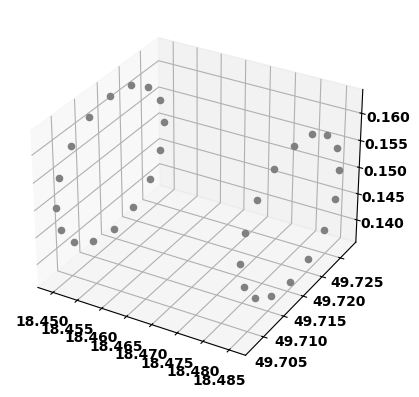

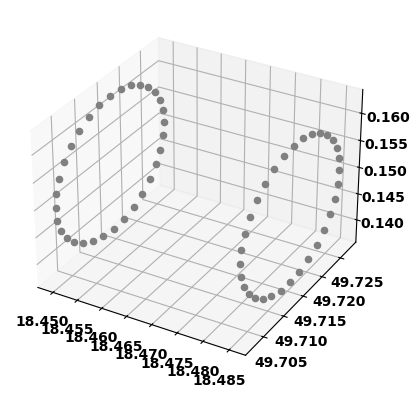

In [112]:
input_v = geom_dict['66957']['vertices']

T_mat_input = get_transformation_matrix(input_v)
v_transformed = np.transpose(T_mat_input @ np.transpose(v_matrix_4))[:, :3]
plot_vertices(input_v)
plot_vertices(v_transformed)

Test 3: Object 90812

<Axes3D: >

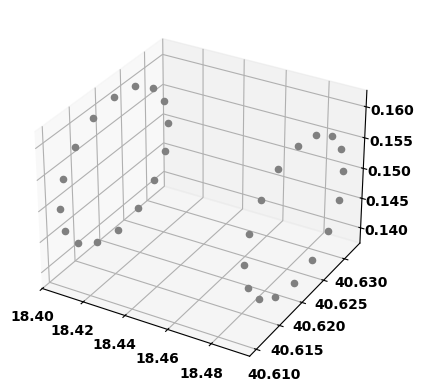

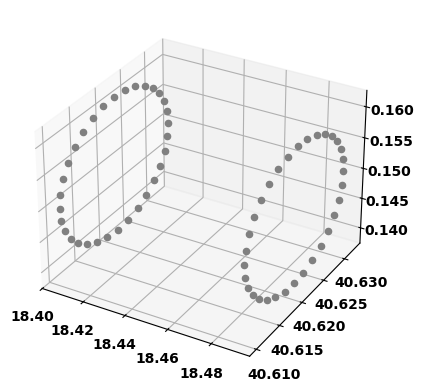

In [113]:
input_v = geom_dict['90812']['vertices']

T_mat_input = get_transformation_matrix(input_v)
v_transformed = np.transpose(T_mat_input @ np.transpose(v_matrix_4))[:, :3]
plot_vertices(input_v)
plot_vertices(v_transformed)

object 89858

<Axes3D: >

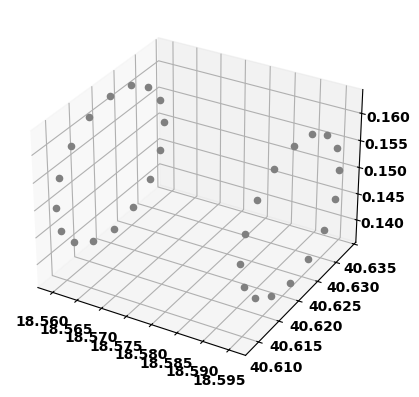

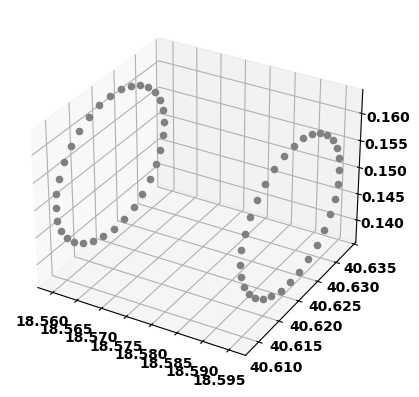

In [114]:
input_v = geom_dict['89858']['vertices']

T_mat_input = get_transformation_matrix(input_v)
v_transformed = np.transpose(T_mat_input @ np.transpose(v_matrix_4))[:, :3]
plot_vertices(input_v)
plot_vertices(v_transformed)

Let's try sampling some pipes from the model and see what we get. Here is a particularly long and diagonal pipe - 3748702

![Test Pipe 1](../img/pipe-test-3748702.png)

<Axes3D: >

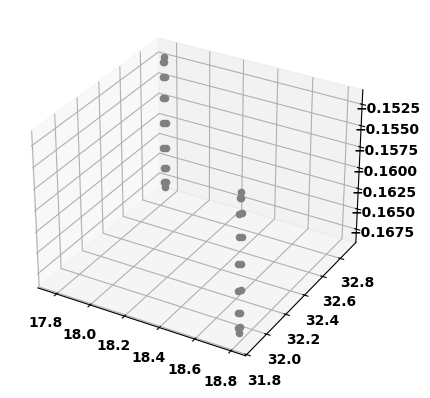

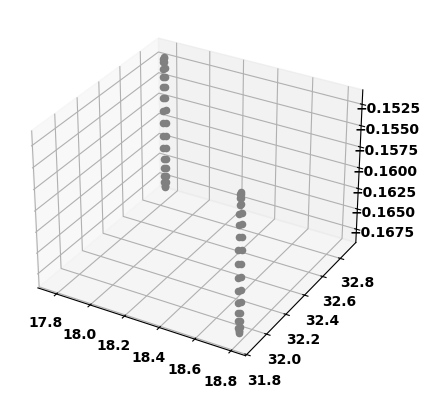

In [115]:
input_v = geom_dict['3748702']['vertices']

T_mat_input = get_transformation_matrix(input_v)
v_transformed = np.transpose(T_mat_input @ np.transpose(v_matrix_4))[:, :3]
plot_vertices(input_v)
plot_vertices(v_transformed)

Here is a pipe that looks shorter than it is wide - 4392112.

![Test pipe 2](../img/pipe-test-4392112.png)

<Axes3D: >

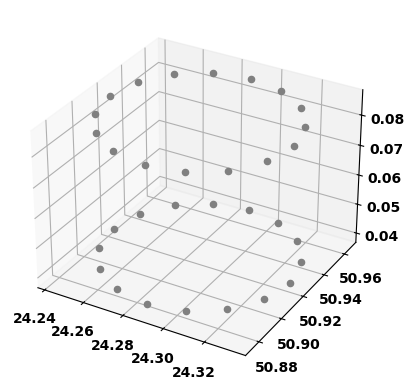

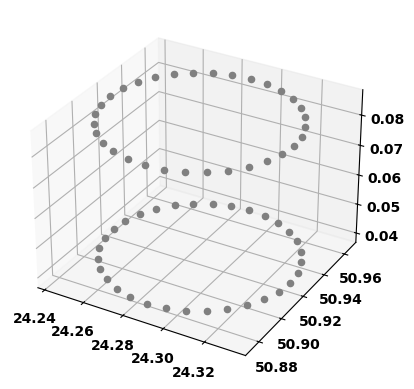

In [116]:
input_v = geom_dict['4392112']['vertices']

T_mat_input = get_transformation_matrix(input_v)
v_transformed = np.transpose(T_mat_input @ np.transpose(v_matrix_4))[:, :3]
plot_vertices(input_v)
plot_vertices(v_transformed)

And here is a pipe that is particularly long and thin - 4033982.

![Test pipe 3](../img/pipe-test-4033982.png)

<Axes3D: >

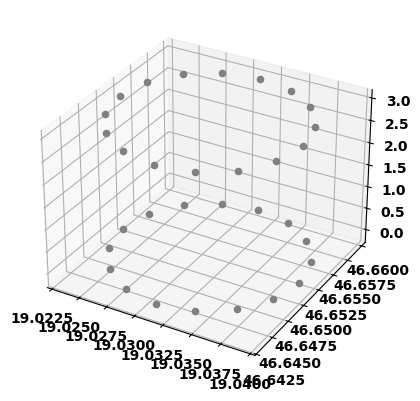

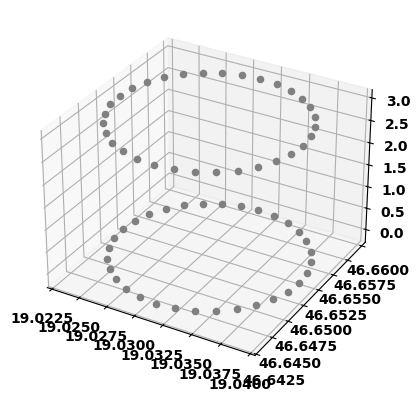

In [117]:
input_v = geom_dict['4033982']['vertices']

T_mat_input = get_transformation_matrix(input_v)
v_transformed = np.transpose(T_mat_input @ np.transpose(v_matrix_4))[:, :3]
plot_vertices(input_v)
plot_vertices(v_transformed)

Lastly, here is a pipe at the very top of our model - 1811108.

![Test pipe 4](../img/pipe-test-1811108.png)

<Axes3D: >

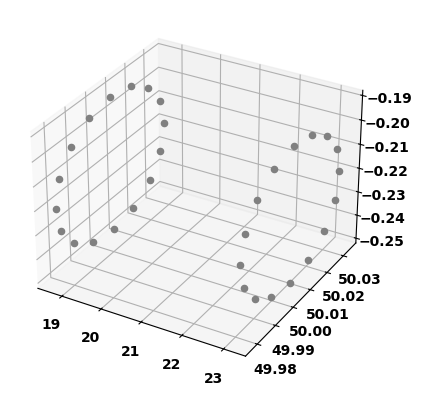

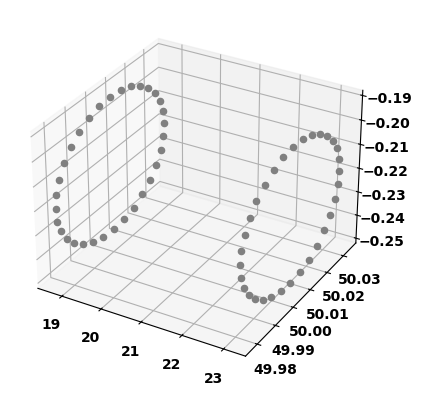

In [118]:
input_v = geom_dict['1811108']['vertices']

T_mat_input = get_transformation_matrix(input_v)
v_transformed = np.transpose(T_mat_input @ np.transpose(v_matrix_4))[:, :3]
plot_vertices(input_v)
plot_vertices(v_transformed)

This looks really good. Let's move on.

## Replacing Geometry

This section will be a little more involved than previous ones. We need to understand the geometry schema of IFC file. We can peruse through the [documentation](https://docs.ifcopenshell.org/ifcopenshell-python/geometry_creation.html#mesh-representations) behind ifcopenshell and gain a little insight. Gemini helps here too.

It seems the core components of a mesh in an IFC file are a representation context, a representation, and a transformation matrix. The representation context is something like a global context provider for each geometry in the scene. It helps determine if we're viewing our objects in 2D view or 3D view. Our existing model should already have one of these, and we can reference it through the element name `IfcGeometricRepresentationContext`.

In [119]:
model.by_type("IfcGeometricRepresentationContext")

[#97=IfcGeometricRepresentationContext($,'Model',3,0.01,#94,#95),
 #100=IfcGeometricRepresentationSubContext('Axis','Model',*,*,*,*,#97,$,.GRAPH_VIEW.,$),
 #102=IfcGeometricRepresentationSubContext('Body','Model',*,*,*,*,#97,$,.MODEL_VIEW.,$),
 #103=IfcGeometricRepresentationSubContext('Box','Model',*,*,*,*,#97,$,.MODEL_VIEW.,$),
 #104=IfcGeometricRepresentationSubContext('FootPrint','Model',*,*,*,*,#97,$,.MODEL_VIEW.,$)]

From the docs, we note that the `body` representation is the most important, and the one that represents the 3D view of the object. Let's extract this attribute. We need to use another import `ifopenshell.util.representation`.

In [120]:
import ifcopenshell.util.representation

model_context = ifcopenshell.util.representation.get_context(model, 'Model')
model_sub_context = ifcopenshell.util.representation.get_context(model, 'Model', 'Body', 'MODEL_VIEW')

print(model_context)
print(model_sub_context)

#97=IfcGeometricRepresentationContext($,'Model',3,0.01,#94,#95)
#102=IfcGeometricRepresentationSubContext('Body','Model',*,*,*,*,#97,$,.MODEL_VIEW.,$)


Once we have a represetation context, we need to now create a `representation`. This will be where the actual geometry of our shape is saved. The representation will also have local coordinates which enable it to be moved around to different locations as needed.

Lastly, the transformation matrix is refered to as the `object placement` attribute and controls where in the scene this object is located.

We also note that Ifc has an innate IfcCylinder object that can be used to create the geometry. Hence, we do not need the test unit cylinder which we had created earlier. Let's see what this object looks like.

In [121]:
axis_placement = model.create_entity(
        "IfcAxis2Placement3D",
        Location=model.create_entity("IfcCartesianPoint", Coordinates=(0.0, 0.0, 0.0))
    )

ifc_cylinder = model.create_entity(
        "IfcRightCircularCylinder",
        Position=axis_placement,
        Radius=0.5,
        Height=1.0
    )

ifc_cylinder

#5077155=IfcRightCircularCylinder(#5077154,1.,0.5)

Upon further research, it seems that this shape does not contain any vertices and faces (since it is a parametric representation), hence we will need to try another approach. Let's work with our unit cylinder from earlier.

To create a mesh representation, we see in the docs that we need to pass a list of vertices an faces. We can use our test unit cylinder from earlier, although we do need to extract the faces array as well.

In [122]:
v_matrix

array([[ 0.      ,  1.      ,  1.      ],
       [ 0.      , -1.      ,  1.      ],
       [ 0.19509 ,  1.      ,  0.980785],
       [ 0.19509 , -1.      ,  0.980785],
       [ 0.382683,  1.      ,  0.92388 ],
       [ 0.382683, -1.      ,  0.923879],
       [ 0.55557 ,  1.      ,  0.83147 ],
       [ 0.55557 , -1.      ,  0.83147 ],
       [ 0.707107,  1.      ,  0.707107],
       [ 0.707107, -1.      ,  0.707107],
       [ 0.83147 ,  1.      ,  0.55557 ],
       [ 0.83147 , -1.      ,  0.55557 ],
       [ 0.92388 ,  1.      ,  0.382683],
       [ 0.92388 , -1.      ,  0.382683],
       [ 0.980785,  1.      ,  0.19509 ],
       [ 0.980785, -1.      ,  0.19509 ],
       [ 1.      ,  1.      ,  0.      ],
       [ 1.      , -1.      , -0.      ],
       [ 0.980785,  1.      , -0.19509 ],
       [ 0.980785, -1.      , -0.19509 ],
       [ 0.92388 ,  1.      , -0.382683],
       [ 0.92388 , -1.      , -0.382683],
       [ 0.83147 ,  1.      , -0.55557 ],
       [ 0.83147 , -1.      , -0.5

In [123]:
f_matrix = m.face_matrix()
f_matrix

array([[ 0,  1,  3],
       [ 0,  3,  2],
       [ 2,  3,  5],
       [ 2,  5,  4],
       [ 4,  5,  7],
       [ 4,  7,  6],
       [ 6,  7,  9],
       [ 6,  9,  8],
       [ 8,  9, 11],
       [ 8, 11, 10],
       [10, 11, 13],
       [10, 13, 12],
       [12, 13, 15],
       [12, 15, 14],
       [14, 15, 17],
       [14, 17, 16],
       [16, 17, 19],
       [16, 19, 18],
       [18, 19, 21],
       [18, 21, 20],
       [20, 21, 23],
       [20, 23, 22],
       [22, 23, 25],
       [22, 25, 24],
       [24, 25, 27],
       [24, 27, 26],
       [26, 27, 29],
       [26, 29, 28],
       [28, 29, 31],
       [28, 31, 30],
       [30, 31, 33],
       [30, 33, 32],
       [32, 33, 35],
       [32, 35, 34],
       [34, 35, 37],
       [34, 37, 36],
       [36, 37, 39],
       [36, 39, 38],
       [38, 39, 41],
       [38, 41, 40],
       [40, 41, 43],
       [40, 43, 42],
       [42, 43, 45],
       [42, 45, 44],
       [44, 45, 47],
       [44, 47, 46],
       [46, 47, 49],
       [46, 4

In [124]:
len(v_matrix)

64

In [125]:
len(f_matrix)

124

Let's see if we can create a cylinder representation using this information.

In [126]:
import ifcopenshell.api.geometry

In [127]:
pipe_representation = ifcopenshell.api.geometry.add_mesh_representation(model, context=model_sub_context, vertices=[ v_matrix ], faces=[ f_matrix ])
pipe_representation

#5077594=IfcShapeRepresentation(#102,'Body','Brep',(#5077593))

A quick note that we need to pass our vertex and face array within a list, since the representation allows for multiple meshes to exist. Hence, the list actually refers to the number of meshes within it, not the number of vertices.

Now that we have a representation, we should be able to assign this representation to each of our pipes in the model. First, let's see what the current representation is for each of our pipes.

In [128]:
pipes = model.by_type('IfcFlowSegment')

ctr = 0

for pipe in pipes:
    ctr += 1

    if ctr == 10:
        break

    current_representation = ifcopenshell.util.representation.get_representation(pipe, context=model_sub_context)

    print(current_representation)

#254=IfcShapeRepresentation(#102,'Body','SweptSolid',(#244))
#401=IfcShapeRepresentation(#102,'Body','SweptSolid',(#391))
#518=IfcShapeRepresentation(#102,'Body','SweptSolid',(#514))
#637=IfcShapeRepresentation(#102,'Body','SweptSolid',(#633))
#752=IfcShapeRepresentation(#102,'Body','SweptSolid',(#748))
#1978=IfcShapeRepresentation(#102,'Body','SweptSolid',(#1974))
#2096=IfcShapeRepresentation(#102,'Body','SweptSolid',(#2092))
#3301=IfcShapeRepresentation(#102,'Body','SweptSolid',(#3297))
#3418=IfcShapeRepresentation(#102,'Body','SweptSolid',(#3414))


Now, let's try reassigning these representations to the one we just created.

In [129]:
# ctr = 0

# for pipe in pipes:
#     ctr += 1

#     if ctr == 10:
#         break
    
#     current_representation = ifcopenshell.util.representation.get_representation(pipe, context=model_sub_context)

#     ifcopenshell.api.geometry.unassign_representation(model, product=pipe, representation=current_representation)
#     ifcopenshell.api.geometry.remove_representation(model, representation=current_representation, should_keep_named_profiles=False)
#     ifcopenshell.api.geometry.assign_representation(model, product=pipe, representation=pipe_representation)

In [130]:
ctr = 0

for pipe in pipes:
    ctr += 1

    if ctr == 10:
        break

    print(pipe)
    
    current_representation = ifcopenshell.util.representation.get_representation(pipe, context=model_sub_context)

    print(current_representation)

#263=IfcFlowSegment('1GU_X06Kf3OPsvt8DGONom',#42,'Pipe Types:Koper_Koper:1363938',$,'Pipe Types:Koper_Koper',#235,#257,'1363938')
#254=IfcShapeRepresentation(#102,'Body','SweptSolid',(#244))
#406=IfcFlowSegment('2ItDDUP057Cx0ZG1SPsdMY',#42,'Pipe Types:DYKA PE Binnenriolering_PE:1688591',$,'Pipe Types:DYKA PE Binnenriolering_PE',#381,#403,'1688591')
#401=IfcShapeRepresentation(#102,'Body','SweptSolid',(#391))
#522=IfcFlowSegment('0gri2Dn6fAiuI7l6OJVHJk',#42,'Pipe Types:DYKA PE Binnenriolering_PE:1695569',$,'Pipe Types:DYKA PE Binnenriolering_PE',#506,#520,'1695569')
#518=IfcShapeRepresentation(#102,'Body','SweptSolid',(#514))
#641=IfcFlowSegment('0gri2Dn6fAiuI7l6OJVHJi',#42,'Pipe Types:DYKA PE Binnenriolering_PE:1695571',$,'Pipe Types:DYKA PE Binnenriolering_PE',#621,#639,'1695571')
#637=IfcShapeRepresentation(#102,'Body','SweptSolid',(#633))
#757=IfcFlowSegment('0gri2Dn6fAiuI7l6OJVHJg',#42,'Pipe Types:DYKA PP Binnenriolering_Afvoerbuis 5m:1695573',$,'Pipe Types:DYKA PP Binnenriolering_

That seemed to work. Now we need to edit the object_placement value according to the transformation matrix.

Lets call back our geometry iterator object.

In [131]:
# iterator = ifcopenshell.geom.iterator(
#     settings, model, include=pipes, geometry_library=geom_library)
# if iterator.initialize():
#     while True:
#         shape = iterator.get()
#         element = model.by_id(shape.id)

#         # shape_id = shape.geometry.id

#         # # From the Docs
#         # matrix = shape.transformation.matrix
#         faces = ifcopenshell.util.shape.get_faces(shape.geometry)
#         verts = ifcopenshell.util.shape.get_vertices(shape.geometry)

#         # Get the transformation matrix

#         T_matrix = get_transformation_matrix(verts)

#         # Replace Current Representation

#         current_representation = ifcopenshell.util.representation.get_representation(element, context=model_sub_context)
        
#         ifcopenshell.api.geometry.unassign_representation(model, product=element, representation=current_representation)
#         ifcopenshell.api.geometry.remove_representation(model, representation=current_representation, should_keep_named_profiles=False)
#         ifcopenshell.api.geometry.assign_representation(model, product=element, representation=pipe_representation)

#         # Edit object placement

#         ifcopenshell.api.geometry.edit_object_placement(model, product=element, matrix=T_matrix)

#         # geom_dict[shape_id] = {}
#         # geom_dict[shape_id]["matrix"] = matrix
#         # geom_dict[shape_id]["faces"] = grouped_faces
#         # geom_dict[shape_id]["vertices"] = grouped_verts

#         if not iterator.next():
#             break

Code commented out for time.

Let's see what the results look like. I'm expected all our objects to have the same ShapeRepresentation.

In [132]:
ctr = 0

for pipe in pipes:
    ctr += 1

    if ctr == 20:
        break
    
    current_representation = ifcopenshell.util.representation.get_representation(pipe, context=model_sub_context)

    print(current_representation)

#254=IfcShapeRepresentation(#102,'Body','SweptSolid',(#244))
#401=IfcShapeRepresentation(#102,'Body','SweptSolid',(#391))
#518=IfcShapeRepresentation(#102,'Body','SweptSolid',(#514))
#637=IfcShapeRepresentation(#102,'Body','SweptSolid',(#633))
#752=IfcShapeRepresentation(#102,'Body','SweptSolid',(#748))
#1978=IfcShapeRepresentation(#102,'Body','SweptSolid',(#1974))
#2096=IfcShapeRepresentation(#102,'Body','SweptSolid',(#2092))
#3301=IfcShapeRepresentation(#102,'Body','SweptSolid',(#3297))
#3418=IfcShapeRepresentation(#102,'Body','SweptSolid',(#3414))
#3533=IfcShapeRepresentation(#102,'Body','SweptSolid',(#3529))
#3649=IfcShapeRepresentation(#102,'Body','SweptSolid',(#3645))
#3766=IfcShapeRepresentation(#102,'Body','SweptSolid',(#3762))
#3883=IfcShapeRepresentation(#102,'Body','SweptSolid',(#3879))
#3998=IfcShapeRepresentation(#102,'Body','SweptSolid',(#3994))
#4279=IfcShapeRepresentation(#102,'Body','SweptSolid',(#4275))
#4394=IfcShapeRepresentation(#102,'Body','SweptSolid',(#4390))
#4

Seems to have worked... Let's save to a file and see what we got.

In [133]:
# model.write('data/plumbing-test.ifc')

Opening this in Blender, this is what we observe.

![First pass](../img/first-pass.png)

Yeah. Something aint right.

Just to cover all bases, let's try setting World Coordinates in our iterator settings to True, and see what we get.

In [134]:
# settings.set(settings.USE_WORLD_COORDS, True)

# iterator = ifcopenshell.geom.iterator(
#     settings, model, include=pipes, geometry_library=geom_library)
# if iterator.initialize():
#     while True:
#         shape = iterator.get()
#         element = model.by_id(shape.id)

#         faces = ifcopenshell.util.shape.get_faces(shape.geometry)
#         verts = ifcopenshell.util.shape.get_vertices(shape.geometry)

#         # Get the transformation matrix
#         T_matrix = get_transformation_matrix(verts)

#         # Replace Current Representation
#         current_representation = ifcopenshell.util.representation.get_representation(element, context=model_sub_context)
        
#         ifcopenshell.api.geometry.unassign_representation(model, product=element, representation=current_representation)
#         ifcopenshell.api.geometry.remove_representation(model, representation=current_representation, should_keep_named_profiles=False)
#         ifcopenshell.api.geometry.assign_representation(model, product=element, representation=pipe_representation)

#         # Edit object placement
#         ifcopenshell.api.geometry.edit_object_placement(model, product=element, matrix=T_matrix)

#         if not iterator.next():
#             break

In [135]:
# model.write('data/plumbing-test.ifc')

![Second Pass](../img/second-pass.png)

That seems much better. Although, the scale still seems off. Let's manually work through a single example.

In [136]:
iterator = ifcopenshell.geom.iterator(
    settings, model, include=pipes, geometry_library=geom_library)

ctr = 0
test_verts = None

if iterator.initialize():
    while True:
        shape = iterator.get()
        element = model.by_id(shape.id)

        faces = ifcopenshell.util.shape.get_faces(shape.geometry)
        verts = ifcopenshell.util.shape.get_vertices(shape.geometry)

        test_verts = verts
        
        # Get the transformation matrix
        T_matrix = get_transformation_matrix(verts)

        # # Replace Current Representation
        # current_representation = ifcopenshell.util.representation.get_representation(element, context=model_sub_context)
        
        # ifcopenshell.api.geometry.unassign_representation(model, product=element, representation=current_representation)
        # ifcopenshell.api.geometry.remove_representation(model, representation=current_representation, should_keep_named_profiles=False)
        # ifcopenshell.api.geometry.assign_representation(model, product=element, representation=pipe_representation)

        # # Edit object placement
        # ifcopenshell.api.geometry.edit_object_placement(model, product=element, matrix=T_matrix)

        ctr += 1

        if ctr == 110:
            break

<Axes3D: >

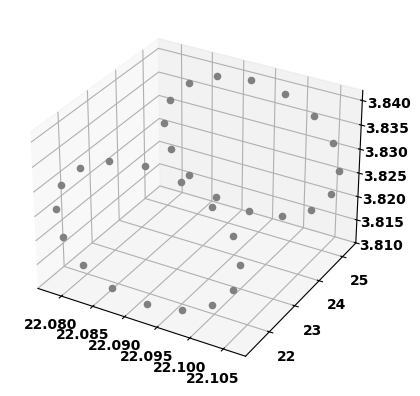

In [137]:
plot_vertices(test_verts)

<Axes3D: >

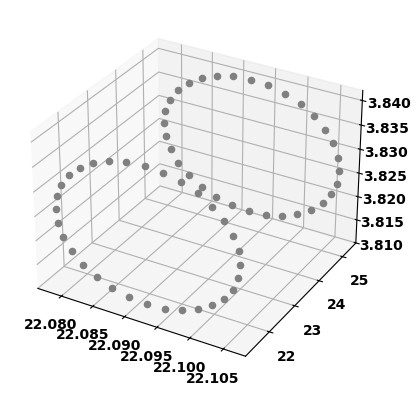

In [138]:
v_transformed = np.transpose(T_matrix @ np.transpose(v_matrix_4))[:, :3]
plot_vertices(v_transformed)

In [139]:
np.min(v_transformed, axis=0)

array([22.0782357 , 21.38393059,  3.812     ])

In [140]:
np.max(v_transformed, axis=0)

array([22.1062357 , 25.29892148,  3.84      ])

In [141]:
# Create world origin placement for the map
origin = model.createIfcCartesianPoint((0.0, 0.0, 0.0))
axis_placement = model.createIfcAxis2Placement3D(origin)

# Create the map using the unit cylinder representation
rep_map = model.createIfcRepresentationMap(axis_placement, pipe_representation)

In [142]:
def get_transformation_matrix_2(input_v):
    '''
    Given a vertex array, finds the transformation matrix required to rotate, scale, and translate a shape into that position. Works best for pipes.

    inputs:
        input_v: numpy array

    returns:
        transformation_matrix: numpy array
        scale_vec: numpy array
    '''
    # Step 1: Center vertices
    centroid = np.min(input_v, axis=0) + (np.max(input_v, axis=0) - np.min(input_v, axis=0))/2
    centered_v = input_v - centroid

    # Step 2: Find covariance matrix
    cov_mat = np.cov(centered_v, rowvar=False)

    # Step 3: Find eigenvectors and values of the cov matrix
    eg_val, eg_vec = np.linalg.eigh(cov_mat)
    eg_val = np.round(eg_val, 4)

    # Step 4: Reorder eigenvector matrix to match length axis
    length_axis = None
    minor_axis_1 = None
    minor_axis_2 = None

    if eg_val[0] == eg_val[1]: 
        length_axis = 2
        minor_axis_1 = 0
        minor_axis_2 = 1

    elif eg_val[0] == eg_val[2]:
        length_axis = 1
        minor_axis_1 = 0
        minor_axis_2 = 2

    elif eg_val[1] == eg_val[2]:
        length_axis = 0
        minor_axis_1 = 2
        minor_axis_2 = 1

    else:
        length_axis = np.nan
        minor_axis_1 = np.nan
        minor_axis_2 = np.nan

    eg_vec = eg_vec[:, [minor_axis_1, length_axis, minor_axis_2]]

    # Step 5: Find scale vector by projecting original verts onto the eg_vectors
    projected_v = centered_v @ eg_vec

    scale_vec = np.max(projected_v, axis = 0)

    # Step 6: Find the final transformation matrix
    T_matrix = np.eye(4, 4)
    T_matrix[:3, :3] = eg_vec
    T_matrix[:3, 3] = centroid

    # Return

    return ( T_matrix, scale_vec )

In [ ]:
settings.set(settings.USE_WORLD_COORDS, True)

iterator = ifcopenshell.geom.iterator(
    settings, model, include=pipes, geometry_library=geom_library)
if iterator.initialize():
    while True:
        shape = iterator.get()
        element = model.by_id(shape.id)

        faces = ifcopenshell.util.shape.get_faces(shape.geometry)
        verts = ifcopenshell.util.shape.get_vertices(shape.geometry)

        # Get the transformation matrix
        T_matrix, scale_vector = get_transformation_matrix_2(verts)

        scale_x, scale_y, scale_z = scale_vector

        operator = model.createIfcCartesianTransformationOperator3DnonUniform(
            LocalOrigin=model.createIfcCartesianPoint((0.0, 0.0, 0.0)),
            Scale=float(scale_x),
            Scale2=float(scale_y),
            Scale3=float(scale_z)
        )

        mapped_item = model.createIfcMappedItem(rep_map, operator)

        # Create Mapped Representation
        mapped_representation = model.createIfcShapeRepresentation(
            ContextOfItems=model_sub_context,
            RepresentationIdentifier='Body',
            RepresentationType='MappedRepresentation',
            Items=[mapped_item]
        )

        # Replace Current Representation
        current_representation = ifcopenshell.util.representation.get_representation(element, context=model_sub_context)
        
        ifcopenshell.api.geometry.unassign_representation(model, product=element, representation=current_representation)
        ifcopenshell.api.geometry.remove_representation(model, representation=current_representation, should_keep_named_profiles=False)
        ifcopenshell.api.geometry.assign_representation(model, product=element, representation=mapped_representation)

        # Edit object placement
        ifcopenshell.api.geometry.edit_object_placement(model, product=element, matrix=T_matrix)

        if not iterator.next():
            break

c:\Users\surya\miniforge3\envs\3dmodelling\Lib\site-packages\ifcopenshell\util\placement.py:42: RuntimeWarning: invalid value encountered in divide
  x = x / np.linalg.norm(x)


In [147]:
representations = model.by_type('IfcShapeRepresentation')
orphan_representations = []

for rep in representations:
    if model.get_total_inverses(rep) == 0:
        orphan_representations.append(rep)

for rep in orphan_representations:
    ifcopenshell.api.run("geometry.remove_representation", model, representation=rep)

In [146]:
import ifcopenshell.api.project

ifcopenshell.api.project.purge(model)

AttributeError: module 'ifcopenshell.api.project' has no attribute 'purge'

In [148]:
model.write('data/plumbing-test_3.ifc')

Test space to create charts.

<Axes3D: >

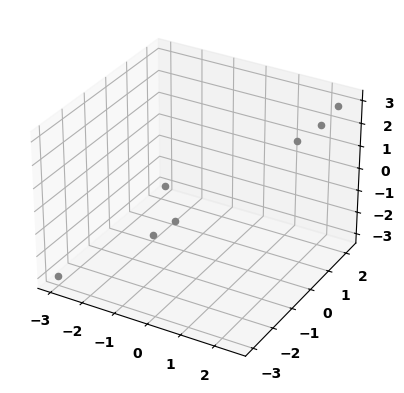

In [18]:
test_chart = [
    [-3,-3,-3],
    [-3,2.2,-3],
    [-1,-1.5,-1.5],
    [0,-2,0],
    [1.3,2,1.0],
    [2,2,2],
    [2.5,2,3]
]

plot_vertices(test_chart)

This file is getting too large to adequately work with. Let's open a new notebook and take it from there.